# Duration Prediction Benchmark — Diagnostic Notebook

Reproduces the WAPE values from the heatmap and decomposes *why* duration prediction fails per process.

Approaches compared:
- **Baseline mean**: always predict the training mean per activity
- **Baseline median**: always predict the training median per activity
- **Global ML** (`ml_plus_global`): one model trained on all activities together
- **Per-act ML** (`ml_plus_per_act`): one model per activity; falls back to statistical if CV score ≥ 95% of baseline

All models replicate `modelling.py` / `sim_extractor.py` exactly.

In [1]:
import os, sys, warnings, ast
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, HuberRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.dummy import DummyRegressor
from xgboost import XGBRegressor
from IPython.display import display

pd.options.mode.chained_assignment = None

SRC_DIR     = Path(os.path.abspath('')).resolve()
REPO_DIR    = SRC_DIR.parent if SRC_DIR.name == 'src' else SRC_DIR
DATA_DIR    = REPO_DIR / 'data' / 'gold' / 'experiment_1'
RESULTS_DIR = REPO_DIR / 'results'

_exp_dirs  = sorted([d for d in RESULTS_DIR.glob('experiment_405_*') if d.is_dir()])
LATEST_EXP = _exp_dirs[-1] if _exp_dirs else None

TRAIN_RATIO      = 0.70
MIN_SAMPLES      = 20
DUR_ACCEPT_RATIO = 0.95
PROCESSES        = ['process_1', 'process_2', 'process_3', 'process_4']

print(f'Data:    {DATA_DIR}')
print(f'Results: {LATEST_EXP}')

Data:    /home/david/repos/process_energy_demand_modelling/data/gold/experiment_1
Results: /home/david/repos/process_energy_demand_modelling/results/experiment_405_20260626_093540


## 1  Load data & temporal split

In [2]:
def _parse_attrs(x):
    if isinstance(x, dict): return x
    if isinstance(x, str):
        try: return ast.literal_eval(x)
        except: return {}
    return {}

def load_and_split(process_name):
    df = pd.read_parquet(DATA_DIR / process_name / 'datasets' / 'df_event_log.parquet')
    df['timestamp_start'] = pd.to_datetime(df['timestamp_start'])
    df['timestamp_end']   = pd.to_datetime(df['timestamp_end'])
    df['duration']        = (df['timestamp_end'] - df['timestamp_start']).dt.total_seconds() / 60.0
    df = df[df['duration'] > 0].copy()
    case_order = df.groupby('case_id')['timestamp_start'].min().sort_values().index.tolist()
    n_train    = max(1, int(len(case_order) * TRAIN_RATIO))
    return (df[df['case_id'].isin(set(case_order[:n_train]))].copy(),
            df[df['case_id'].isin(set(case_order[n_train:]))].copy())

datasets = {}
for proc in PROCESSES:
    tr, te = load_and_split(proc)
    datasets[proc] = {'train': tr, 'test': te}
    print(f"{proc}: {tr['case_id'].nunique()} train / {te['case_id'].nunique()} test cases | {tr['activity'].nunique()} activities")

process_1: 1533 train / 657 test cases | 22 activities
process_2: 34 train / 15 test cases | 12 activities
process_3: 221 train / 95 test cases | 5 activities
process_4: 37 train / 16 test cases | 13 activities


## 2  Per-activity duration statistics

**CV** = σ/μ measures intrinsic predictability.  **Shift** = |μ_train − μ_test|/μ_test measures distribution drift.  
Red = problematic; yellow = too few samples for ML.

In [3]:
stat_rows = []
for proc, ds in datasets.items():
    tr, te = ds['train'], ds['test']
    for act in sorted(tr['activity'].unique()):
        tr_a = tr[tr['activity'] == act]['duration']
        te_a = te[te['activity'] == act]['duration'] if act in te['activity'].values else pd.Series([], dtype=float)
        mu_tr  = tr_a.mean()   if len(tr_a) > 0 else np.nan
        mu_te  = te_a.mean()   if len(te_a) > 0 else np.nan
        cv_tr  = tr_a.std() / mu_tr if (mu_tr and mu_tr > 0 and len(tr_a) > 1) else np.nan
        shift  = abs(mu_tr - mu_te) / mu_te if (mu_te and mu_te > 0) else np.nan
        stat_rows.append({'process': proc, 'activity': act,
                          'n_train': len(tr_a), 'n_test': len(te_a),
                          'mean_train': round(mu_tr, 2), 'mean_test': round(mu_te, 2),
                          'cv_train': round(cv_tr, 3), 'mean_shift': round(shift, 3)})

stats_df = pd.DataFrame(stat_rows)
display(stats_df.style
    .applymap(lambda v: 'background-color:#ffd6d6' if (not pd.isna(v) and v > 0.3) else '', subset=['mean_shift'])
    .applymap(lambda v: 'background-color:#ffd6d6' if (not pd.isna(v) and v > 0.5) else '', subset=['cv_train'])
    .applymap(lambda v: 'background-color:#fff3cd' if (not pd.isna(v) and v < MIN_SAMPLES) else '', subset=['n_train'])
    .set_caption('Red=problematic | Yellow=too few samples for ML'))

,process,activity,n_train,n_test,mean_train,mean_test,cv_train,mean_shift
0,process_1,autoclaving_1_cool,511,219,25.420000,25.740000,0.205000,0.013000
1,process_1,autoclaving_1_heat,511,219,16.410000,16.550000,0.196000,0.009000
2,process_1,autoclaving_1_hold,511,219,12.600000,12.740000,0.223000,0.011000
3,process_1,autoclaving_1_prepare,409,180,2.000000,2.000000,0.020000,0.001000
4,process_1,autoclaving_2_cool,511,219,25.500000,25.660000,0.203000,0.006000
5,process_1,autoclaving_2_heat,511,219,16.440000,16.560000,0.194000,0.007000
6,process_1,autoclaving_2_hold,511,219,12.650000,12.760000,0.220000,0.009000
7,process_1,autoclaving_2_prepare,412,180,2.000000,2.000000,0.020000,0.000000
8,process_1,autoclaving_3_cool,511,219,25.080000,25.300000,0.217000,0.009000
9,process_1,autoclaving_3_heat,511,219,16.190000,16.380000,0.208000,0.012000


## 3  Duration distribution plots (train vs test)

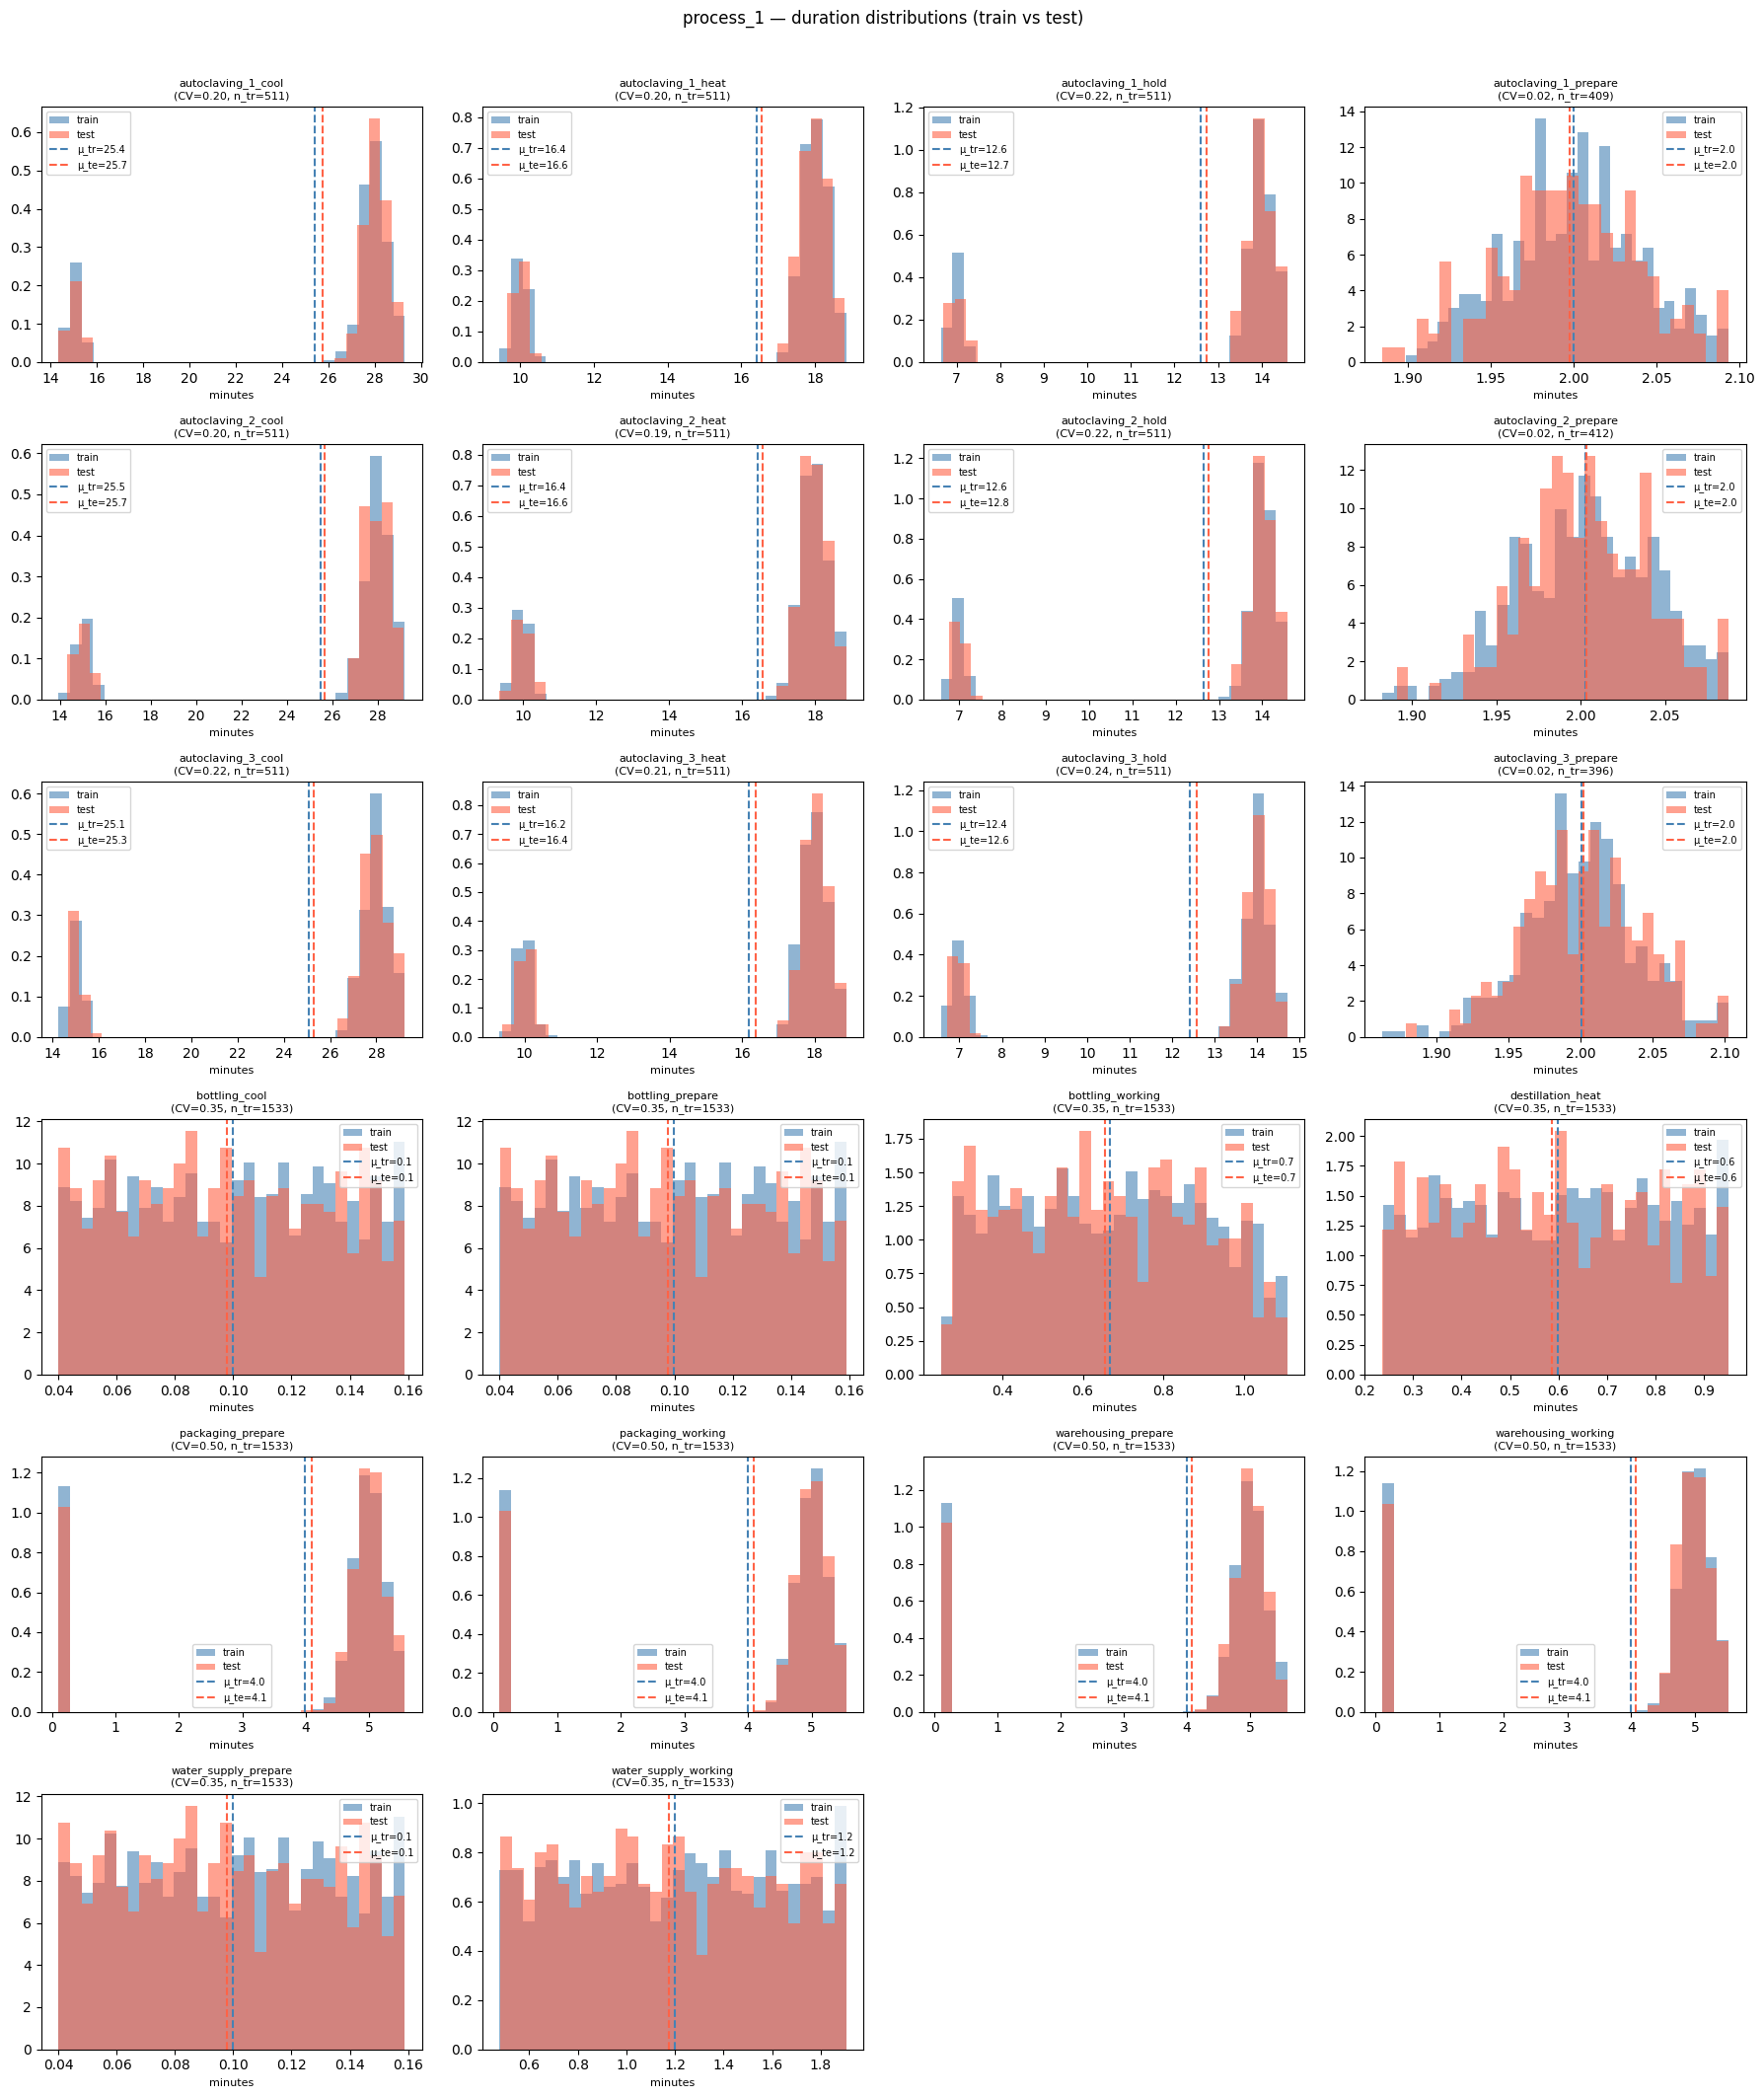

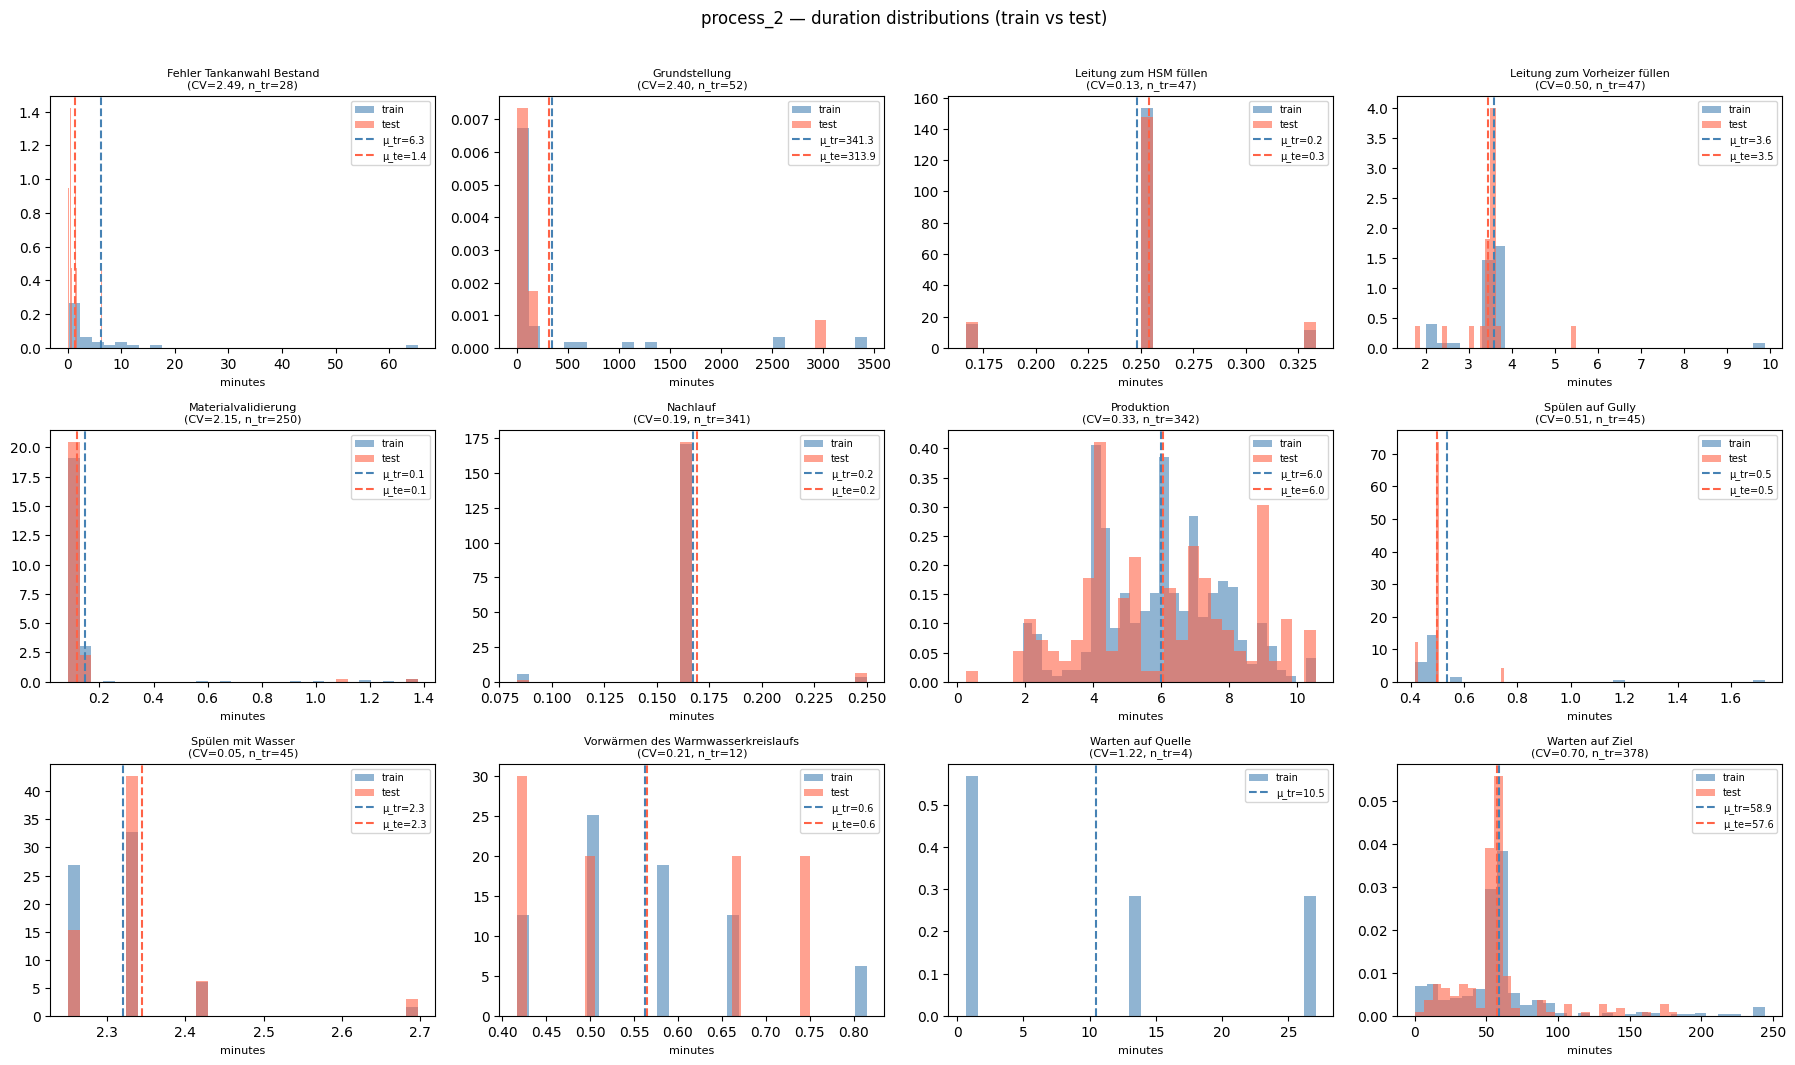

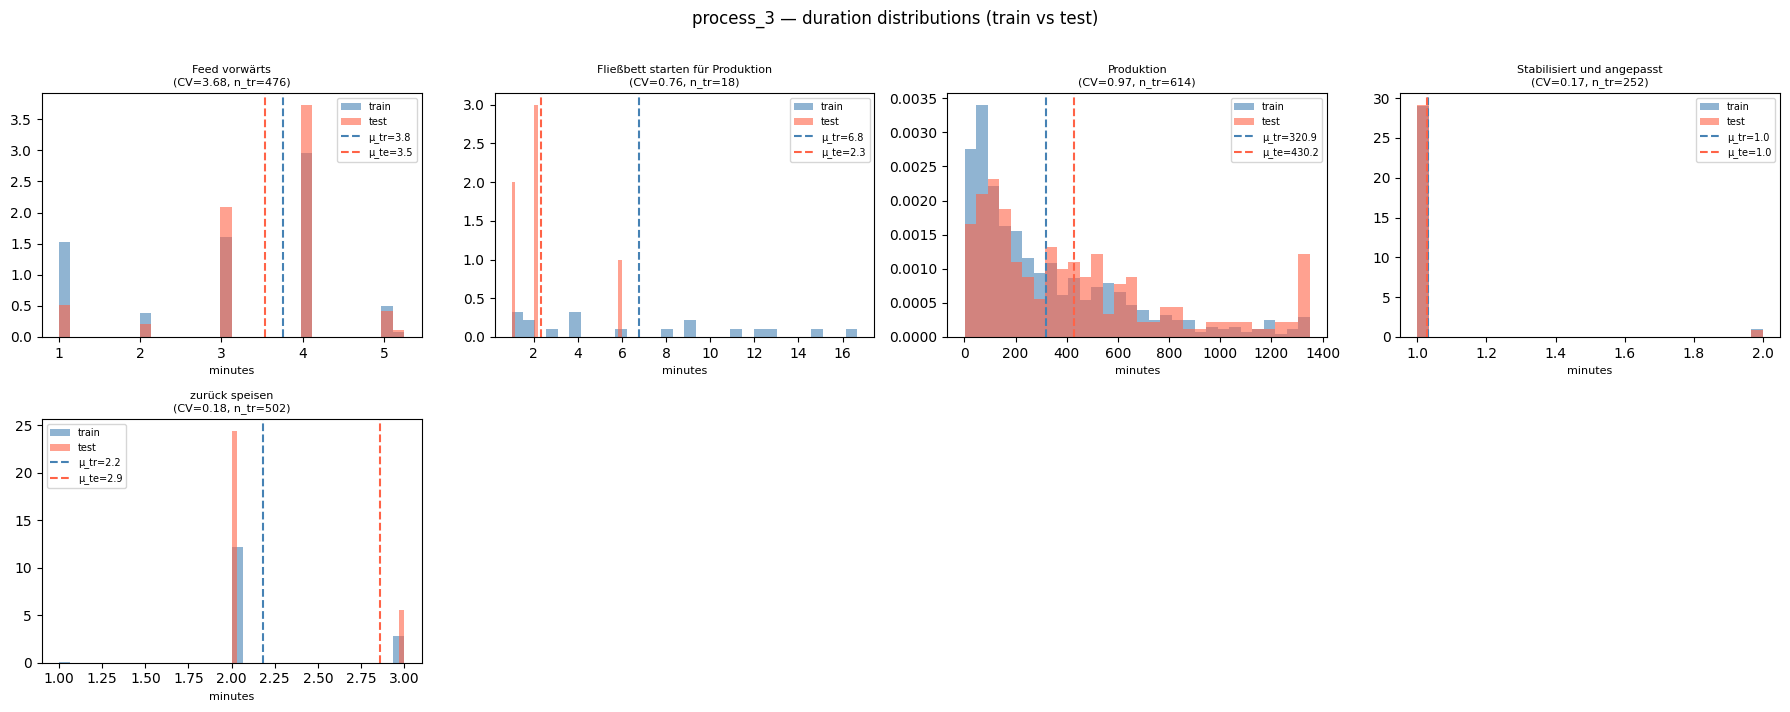

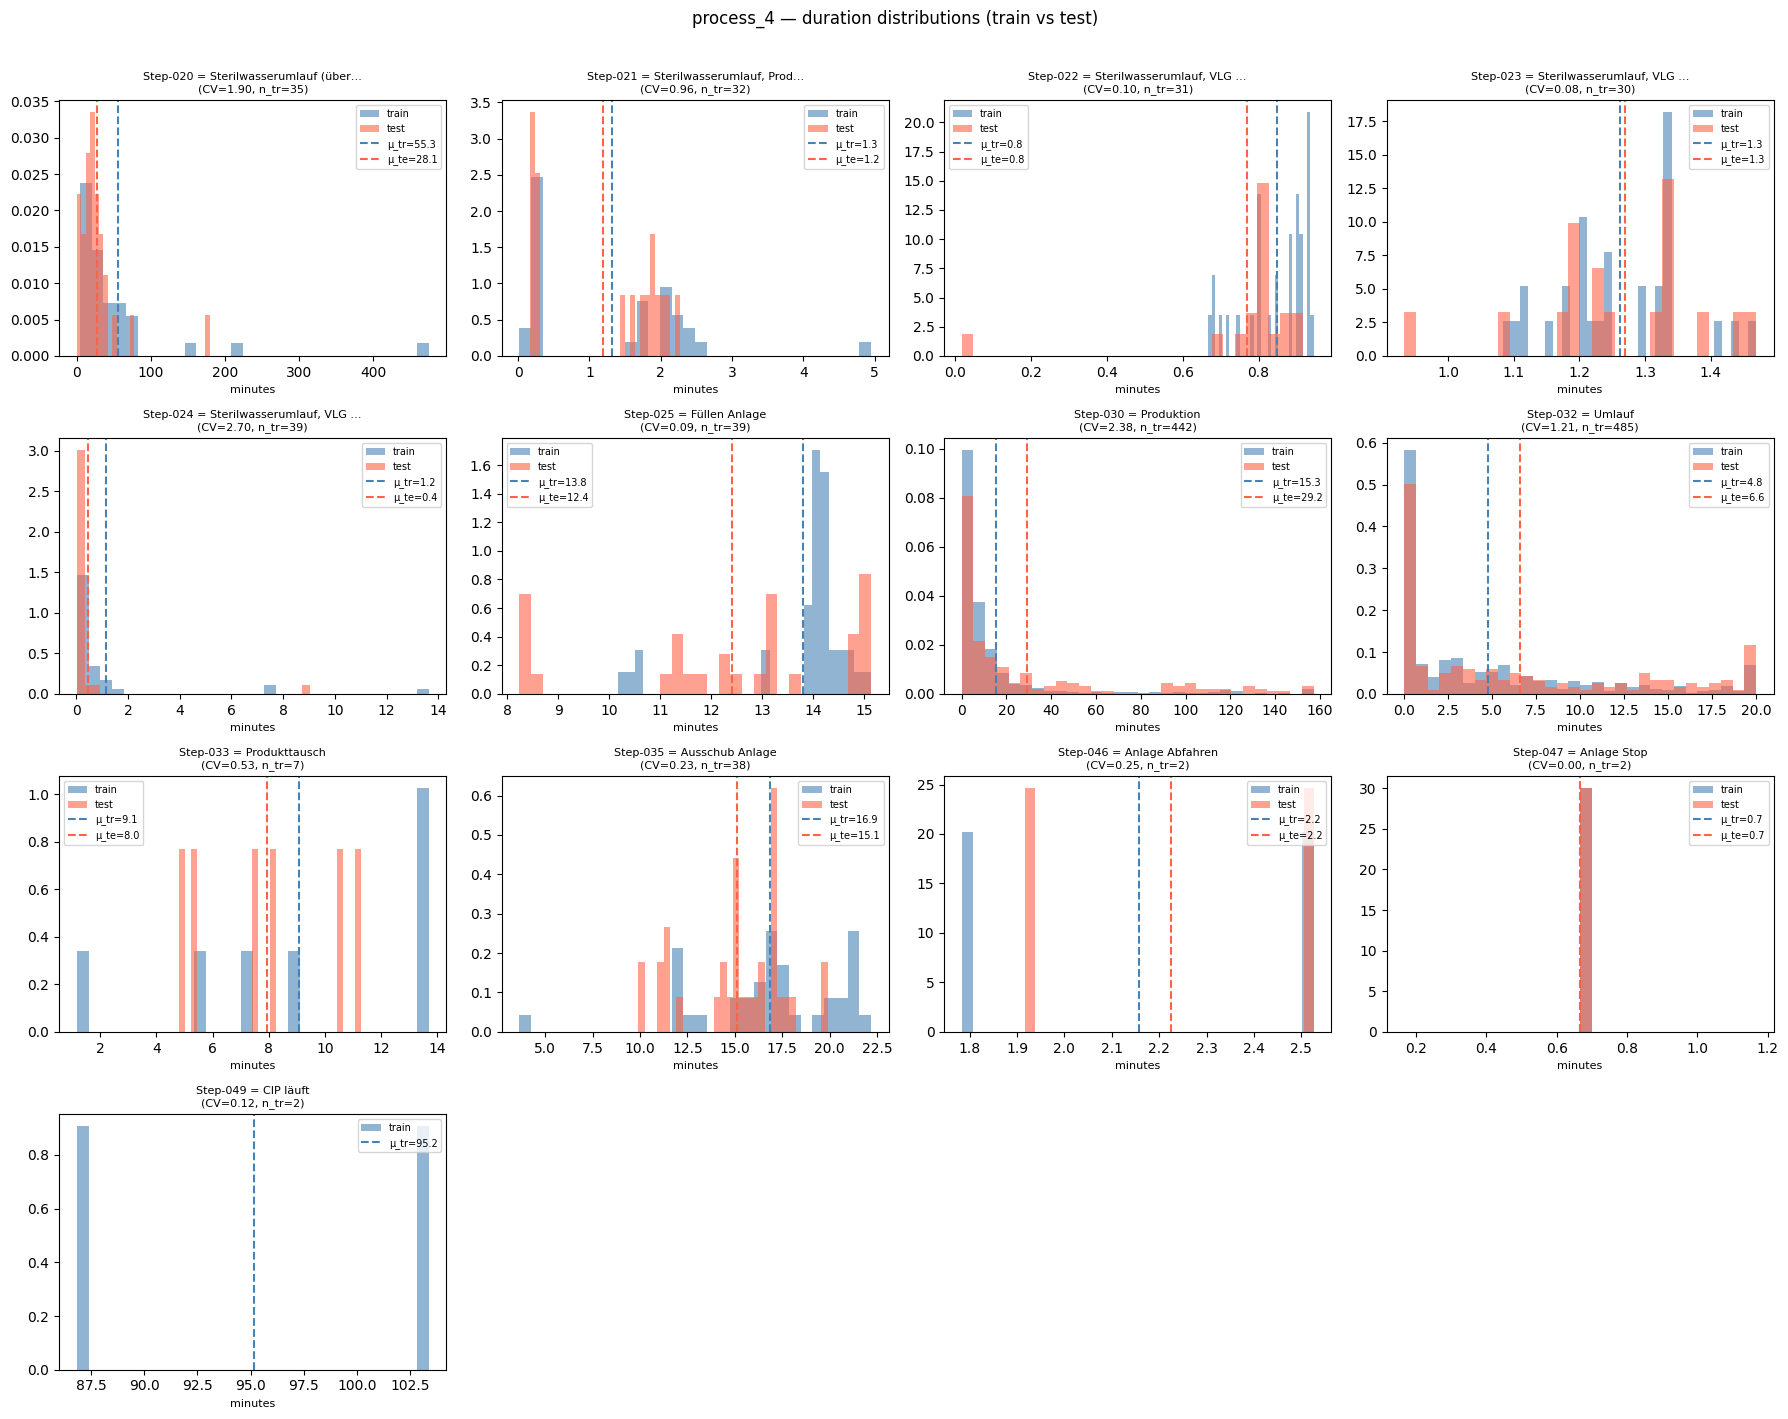

In [4]:
for proc, ds in datasets.items():
    tr, te = ds['train'], ds['test']
    activities = sorted(tr['activity'].unique())
    n_cols = min(4, len(activities))
    n_rows = int(np.ceil(len(activities) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5*n_cols, 3.5*n_rows))
    axes = np.array(axes).flatten()
    for i, act in enumerate(activities):
        ax   = axes[i]
        tr_d = tr[tr['activity']==act]['duration'].dropna()
        te_d = te[te['activity']==act]['duration'].dropna() if act in te['activity'].values else pd.Series([])
        clip = np.percentile(tr_d, 99) if len(tr_d) > 1 else tr_d.max()
        ax.hist(tr_d.clip(upper=clip), bins=30, alpha=0.6, density=True, label='train', color='steelblue')
        if len(te_d): ax.hist(te_d.clip(upper=clip), bins=30, alpha=0.6, density=True, label='test', color='tomato')
        ax.axvline(tr_d.mean(), color='steelblue', ls='--', lw=1.5, label=f'μ_tr={tr_d.mean():.1f}')
        if len(te_d): ax.axvline(te_d.mean(), color='tomato', ls='--', lw=1.5, label=f'μ_te={te_d.mean():.1f}')
        cv = tr_d.std()/tr_d.mean() if tr_d.mean()>0 else 0
        ax.set_title(f"{act[:35]}{'…' if len(act)>35 else ''}\n(CV={cv:.2f}, n_tr={len(tr_d)})", fontsize=8)
        ax.legend(fontsize=7); ax.set_xlabel('minutes', fontsize=8)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    fig.suptitle(f'{proc} — duration distributions (train vs test)', fontsize=12, y=1.01)
    plt.tight_layout(); plt.show()

## 4  Feature engineering & model training

In [5]:
def prepare_features(df, activity_means, global_mean):
    """Mirror of _mlp_flatten_object_attributes + _mlp_add_features in modelling.py."""
    out = df.copy()
    if 'object_attributes' in out.columns:
        attrs   = out['object_attributes'].apply(_parse_attrs)
        attr_df = pd.json_normalize(attrs.tolist()).add_prefix('attr_')
        attr_df.index = out.index
        out = pd.concat([out.drop(columns=['object_attributes']), attr_df], axis=1)
    out = out.sort_values(['case_id', 'timestamp_start'])
    out['feat_hour']         = out['timestamp_start'].dt.hour
    out['feat_dayofweek']    = out['timestamp_start'].dt.dayofweek
    out['feat_month']        = out['timestamp_start'].dt.month
    out['feat_act_pos']      = out.groupby('case_id').cumcount()
    out['feat_prev_dur']     = out.groupby('case_id')['duration'].shift(1).fillna(0.0)
    out['feat_prev_dur2']    = out.groupby('case_id')['duration'].shift(2).fillna(0.0)
    out['feat_case_elapsed'] = (out['timestamp_start']
        - out.groupby('case_id')['timestamp_start'].transform('min')).dt.total_seconds()/60.0
    out['feat_act_mean_dur'] = out['activity'].map(activity_means).fillna(global_mean)
    attr_cols = [c for c in out.columns if c.startswith('attr_')]
    num_attr  = [c for c in attr_cols if pd.to_numeric(out[c], errors='coerce').notna().mean()>0.5]
    eng_cols  = ['feat_hour','feat_dayofweek','feat_month','feat_act_pos',
                 'feat_prev_dur','feat_prev_dur2','feat_case_elapsed','feat_act_mean_dur']
    feat_cols = [c for c in (num_attr + eng_cols) if c in out.columns]
    return out, feat_cols

def make_X(df, feat_cols):
    return df[feat_cols].apply(pd.to_numeric, errors='coerce').fillna(0).values

CANDS = {
    'ridge': lambda: Ridge(alpha=1.0),
    'huber': lambda: HuberRegressor(epsilon=1.35, max_iter=300),
    'rf'   : lambda: RandomForestRegressor(n_estimators=50, max_depth=5, min_samples_leaf=3, random_state=42),
    'xgb'  : lambda: XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05, subsample=0.8, random_state=42, verbosity=0),
}

def _cv_mae(X, y_log, k):
    kf, scores = KFold(n_splits=k, shuffle=False), {}
    for name, make in CANDS.items():
        s = []
        for tr_i, va_i in kf.split(X):
            sc, m = StandardScaler(), make()
            try:
                m.fit(sc.fit_transform(X[tr_i]), y_log[tr_i])
                s.append(np.mean(np.abs(m.predict(sc.transform(X[va_i])) - y_log[va_i])))
            except: pass
        if s: scores[name] = float(np.mean(s))
    return scores

def train_global(df_tr, feat_cols):
    y_log = np.log1p(df_tr['duration'].values)
    X     = make_X(df_tr, feat_cols)
    k     = min(5, len(df_tr)//2)
    if k < 2: return None, None, 'fallback', {}
    scores    = _cv_mae(X, y_log, k)
    best_name = min(scores, key=scores.get)
    sc, m     = StandardScaler(), CANDS[best_name]()
    m.fit(sc.fit_transform(X), y_log)
    return m, sc, best_name, scores

def train_per_act(df_tr, feat_cols):
    result = {}
    for act, sub in df_tr.groupby('activity'):
        mu_d  = sub['duration'].mean()
        med_d = sub['duration'].median()
        base  = {'type':'stat','mean_dur':mu_d,'median_dur':med_d,'n':len(sub),
                 'cv_score':np.nan,'baseline_score':np.nan,'improvement':0.0,'model_name':'statistical'}
        if len(sub) < MIN_SAMPLES:
            result[str(act)] = base; continue
        y_log = np.log1p(sub['duration'].values)
        X     = make_X(sub, feat_cols)
        k     = min(5, len(sub)//2)
        if k < 2:
            result[str(act)] = base; continue
        kf  = KFold(n_splits=k, shuffle=False)
        b_mae = float(-cross_val_score(DummyRegressor(strategy='mean'), X, y_log,
                      cv=kf, scoring='neg_mean_absolute_error', error_score=np.inf).mean())
        scores = _cv_mae(X, y_log, k)
        if not scores:
            result[str(act)] = base; continue
        best_name, best_score = min(scores.items(), key=lambda kv: kv[1])
        base['cv_score'] = best_score; base['baseline_score'] = b_mae
        if best_score >= DUR_ACCEPT_RATIO * b_mae:
            base['improvement'] = 0.0
            result[str(act)] = base
        else:
            sc, m = StandardScaler(), CANDS[best_name]()
            m.fit(sc.fit_transform(X), y_log)
            result[str(act)] = {'type':'ml','model':m,'scaler':sc,'model_name':best_name,
                                'mean_dur':mu_d,'median_dur':med_d,'n':len(sub),
                                'cv_score':best_score,'baseline_score':b_mae,
                                'improvement':1.0-best_score/b_mae}
    return result

proc_models = {}
for proc in PROCESSES:
    print(f'\n── {proc} ──')
    tr = datasets[proc]['train']
    act_means   = tr.groupby('activity')['duration'].median().to_dict()
    global_mean = float(tr['duration'].median())
    tr_f, feat_cols = prepare_features(tr, act_means, global_mean)
    print(f'  Features ({len(feat_cols)}): {feat_cols}')
    gm, gs, gname, gscores = train_global(tr_f, feat_cols)
    if gscores: print(f'  Global best: {gname}  CV-MAE(log1p): {min(gscores.values()):.4f} | all: { {k:round(v,4) for k,v in gscores.items()} }')
    act_mods = train_per_act(tr_f, feat_cols)
    n_ml  = sum(1 for v in act_mods.values() if v['type']=='ml')
    n_sta = sum(1 for v in act_mods.values() if v['type']=='stat')
    print(f'  Per-act: {n_ml} ML accepted, {n_sta} statistical fallback')
    proc_models[proc] = {'global_model':gm,'global_scaler':gs,'global_name':gname,
                         'act_models':act_mods,'feat_cols':feat_cols,
                         'act_means':act_means,'global_mean':global_mean}


── process_1 ──
  Features (9): ['attr_volume_L', 'feat_hour', 'feat_dayofweek', 'feat_month', 'feat_act_pos', 'feat_prev_dur', 'feat_prev_dur2', 'feat_case_elapsed', 'feat_act_mean_dur']
  Global best: xgb  CV-MAE(log1p): 0.0364 | all: {'ridge': 0.326, 'huber': 0.3149, 'rf': 0.0526, 'xgb': 0.0364}
  Per-act: 19 ML accepted, 3 statistical fallback

── process_2 ──
  Features (12): ['attr_mat_id_m01_', 'attr_mat_id_m02_', 'attr_mat_id_m03_', 'attr_total_material', 'feat_hour', 'feat_dayofweek', 'feat_month', 'feat_act_pos', 'feat_prev_dur', 'feat_prev_dur2', 'feat_case_elapsed', 'feat_act_mean_dur']
  Global best: rf  CV-MAE(log1p): 0.2346 | all: {'ridge': 0.622, 'huber': 0.5964, 'rf': 0.2346, 'xgb': 0.2397}
  Per-act: 8 ML accepted, 4 statistical fallback

── process_3 ──
  Features (9): ['attr_total_material', 'feat_hour', 'feat_dayofweek', 'feat_month', 'feat_act_pos', 'feat_prev_dur', 'feat_prev_dur2', 'feat_case_elapsed', 'feat_act_mean_dur']
  Global best: rf  CV-MAE(log1p): 0.43

## 5  WAPE on test set

$$\text{WAPE} = 100 \times \frac{\sum_a |\hat{\mu}_a - \mu_a|}{\sum_a \mu_a}$$

Same formula as `comprehensive_simulation_evaluation` in `modelling.py`.

In [6]:
def wape_from_preds(df_te, preds):
    df = df_te.copy(); df['pred'] = preds.values
    rmu = df.groupby('activity')['duration'].mean()
    pmu = df.groupby('activity')['pred'].mean()
    c   = rmu.index.intersection(pmu.index)
    return float(np.sum(np.abs(pmu[c]-rmu[c]))/np.sum(rmu[c]))*100, np.abs(pmu[c]-rmu[c]), rmu[c], pmu[c]

def predict_test(proc, approach):
    m  = proc_models[proc]
    tr = datasets[proc]['train']
    te = datasets[proc]['test']
    act_means   = m['act_means']
    act_medians = tr.groupby('activity')['duration'].median().to_dict()
    te_f, feat_cols = prepare_features(te, act_means, m['global_mean'])
    if approach == 'mean_baseline':
        return te_f['activity'].map(act_means).fillna(m['global_mean'])
    if approach == 'median_baseline':
        return te_f['activity'].map(act_medians).fillna(tr['duration'].median())
    if approach == 'global_ml':
        if m['global_model'] is None: return te_f['activity'].map(act_means).fillna(m['global_mean'])
        X = make_X(te_f, feat_cols)
        return pd.Series(np.maximum(np.expm1(m['global_model'].predict(m['global_scaler'].transform(X))), 0.01), index=te_f.index)
    if approach == 'per_act_ml':
        preds = pd.Series(np.nan, index=te_f.index)
        for act, sub in te_f.groupby('activity'):
            info = m['act_models'].get(str(act))
            if info is None or info['type']=='stat':
                preds.loc[sub.index] = act_means.get(act, m['global_mean'])
            else:
                X = make_X(sub, feat_cols)
                preds.loc[sub.index] = np.maximum(np.expm1(info['model'].predict(info['scaler'].transform(X))), 0.01)
        return preds.fillna(m['global_mean'])
    raise ValueError(approach)

APPROACHES = ['mean_baseline', 'median_baseline', 'global_ml', 'per_act_ml']
wape_rows  = []
detail     = {}

for proc in PROCESSES:
    te = datasets[proc]['test']
    for appr in APPROACHES:
        preds = predict_test(proc, appr)
        te_tmp = te.copy(); te_tmp['pred'] = preds.reindex(te.index)
        w, ae, rmu, pmu = wape_from_preds(te_tmp, te_tmp['pred'])
        wape_rows.append({'process':proc,'approach':appr,'WAPE_%':round(w,2)})
        detail[(proc,appr)] = {'abs_err':ae,'real_mu':rmu,'pred_mu':pmu}

wape_df = pd.DataFrame(wape_rows).pivot(index='approach', columns='process', values='WAPE_%')
print('Prediction WAPE on test set (lower = better):')
display(wape_df.style.background_gradient(cmap='RdYlGn_r', axis=None).format('{:.1f}%'))

Prediction WAPE on test set (lower = better):


process,process_1,process_2,process_3,process_4
approach,,,,
global_ml,2.7%,68.9%,54.4%,41.9%
mean_baseline,9.5%,70.4%,50.6%,33.5%
median_baseline,9.5%,70.4%,50.6%,33.5%
per_act_ml,0.2%,70.6%,53.2%,466.9%


## 6  Comparison with stored heatmap

In [7]:
if LATEST_EXP is not None and (LATEST_EXP / 'process_eval_results.parquet').exists():
    sim_df = pd.read_parquet(LATEST_EXP / 'process_eval_results.parquet')
    def _mode_type(mode):
        if 'ml_plus_per_act' in mode: return 'per_act_ml'
        if 'ml_plus_global'  in mode: return 'global_ml'
        if mode == 'statistical':     return 'mean_baseline'
        return 'petri_net_stat'
    sim_df['_type'] = sim_df['mode'].apply(_mode_type)
    sim_best = (sim_df[sim_df['_type'].isin(['mean_baseline','global_ml','per_act_ml'])]
                .groupby(['_type','process'])['test_duration_metrics_activity_duration_wape']
                .min().unstack('process'))
    sim_best.index.name = 'approach'
    print('Heatmap WAPE (best per approach — full simulation pipeline):')
    display(sim_best.round(1).style.background_gradient(cmap='RdYlGn_r', axis=None).format('{:.1f}%'))
    print('\nNotebook direct-prediction WAPE (ML prediction on actual test cases):')
    display(wape_df.style.background_gradient(cmap='RdYlGn_r', axis=None).format('{:.1f}%'))
    print('\nNote: Difference = what is lost in the simulation sampling step vs. the ML model itself.')
else:
    print('No stored heatmap found.')

Heatmap WAPE (best per approach — full simulation pipeline):


process,process_1,process_2,process_3,process_4
approach,,,,
global_ml,8.1%,17.4%,56.9%,35.3%
mean_baseline,32.8%,40.6%,68.6%,46.8%
per_act_ml,3.8%,22.5%,55.2%,31.0%



Notebook direct-prediction WAPE (ML prediction on actual test cases):


process,process_1,process_2,process_3,process_4
approach,,,,
global_ml,2.7%,68.9%,54.4%,41.9%
mean_baseline,9.5%,70.4%,50.6%,33.5%
median_baseline,9.5%,70.4%,50.6%,33.5%
per_act_ml,0.2%,70.6%,53.2%,466.9%



Note: Difference = what is lost in the simulation sampling step vs. the ML model itself.


## 7  Per-activity WAPE breakdown

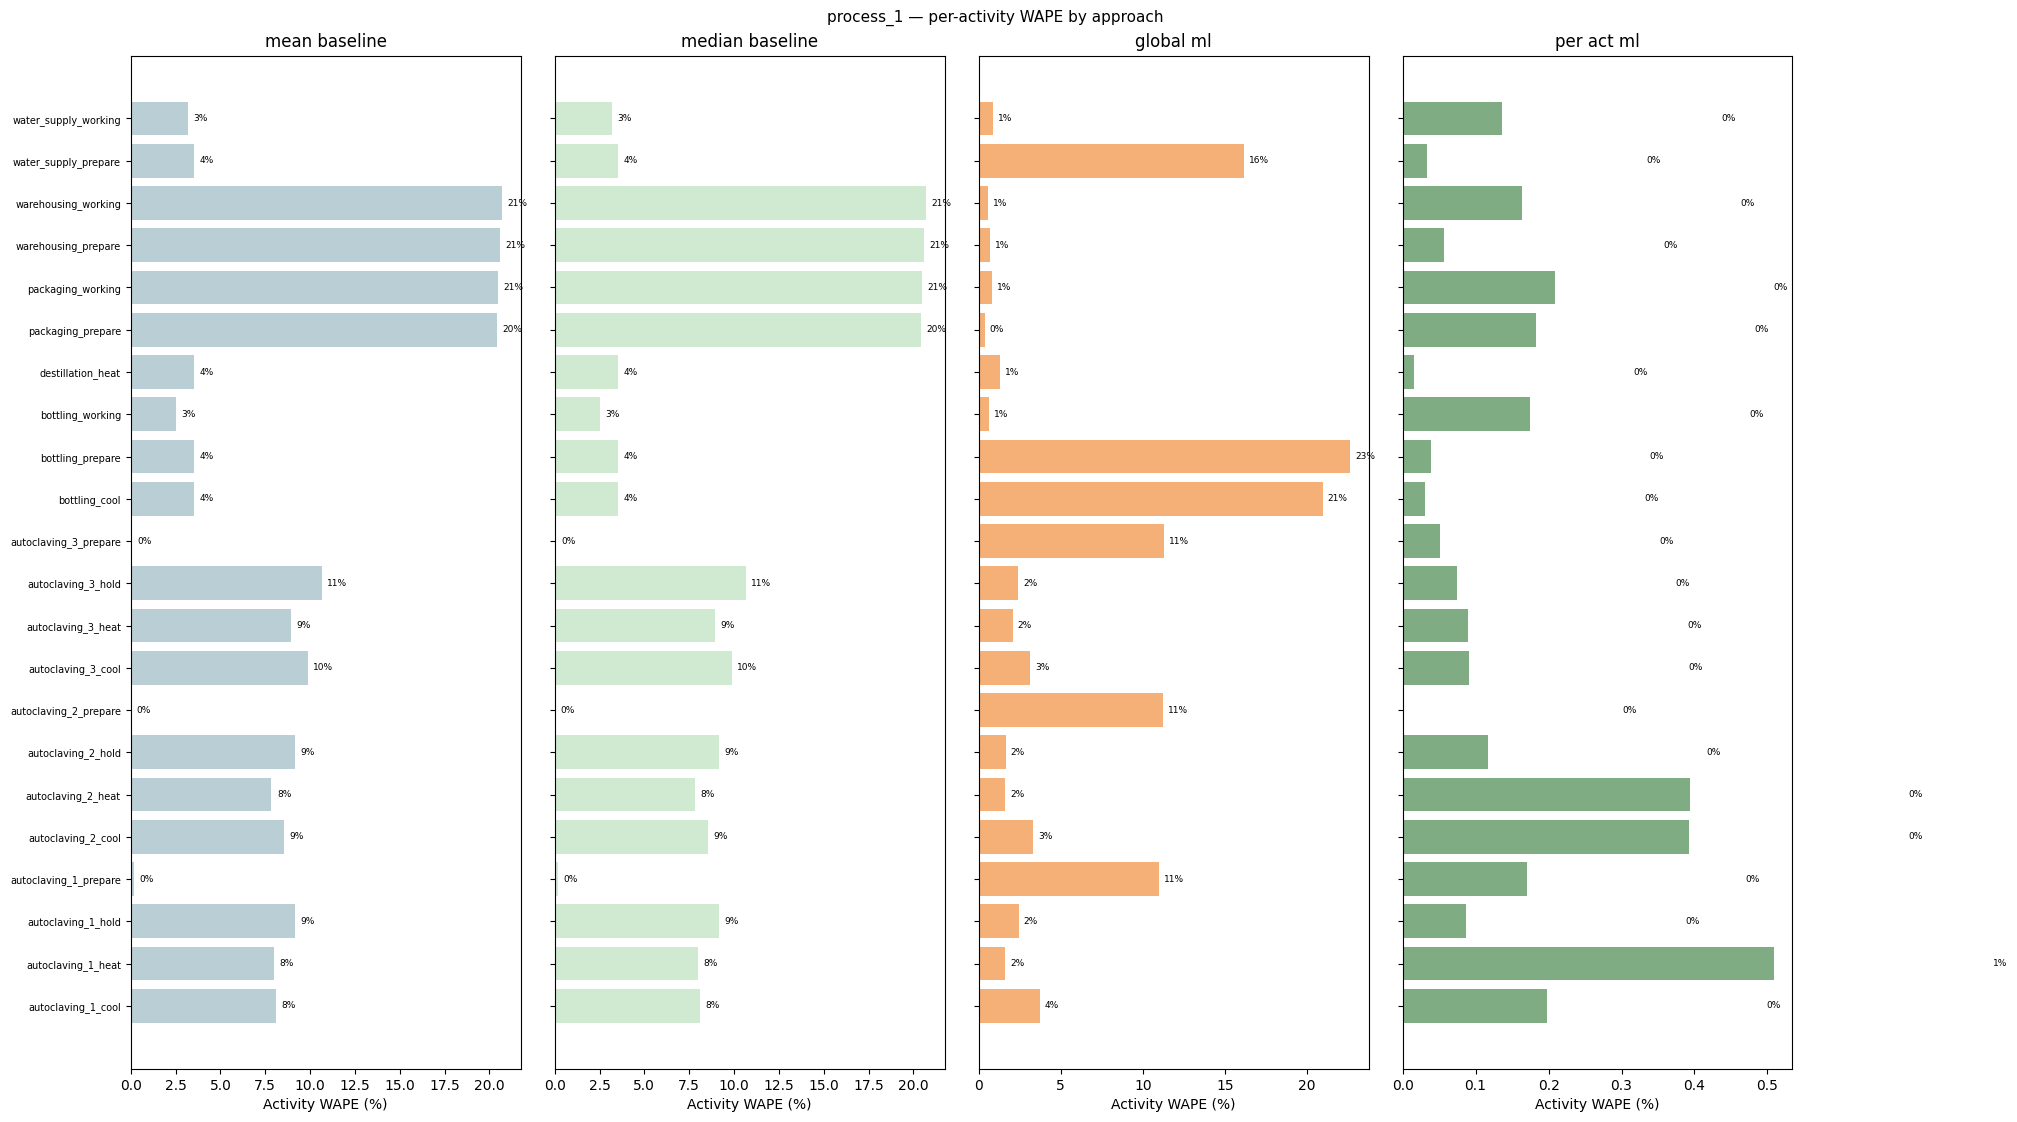

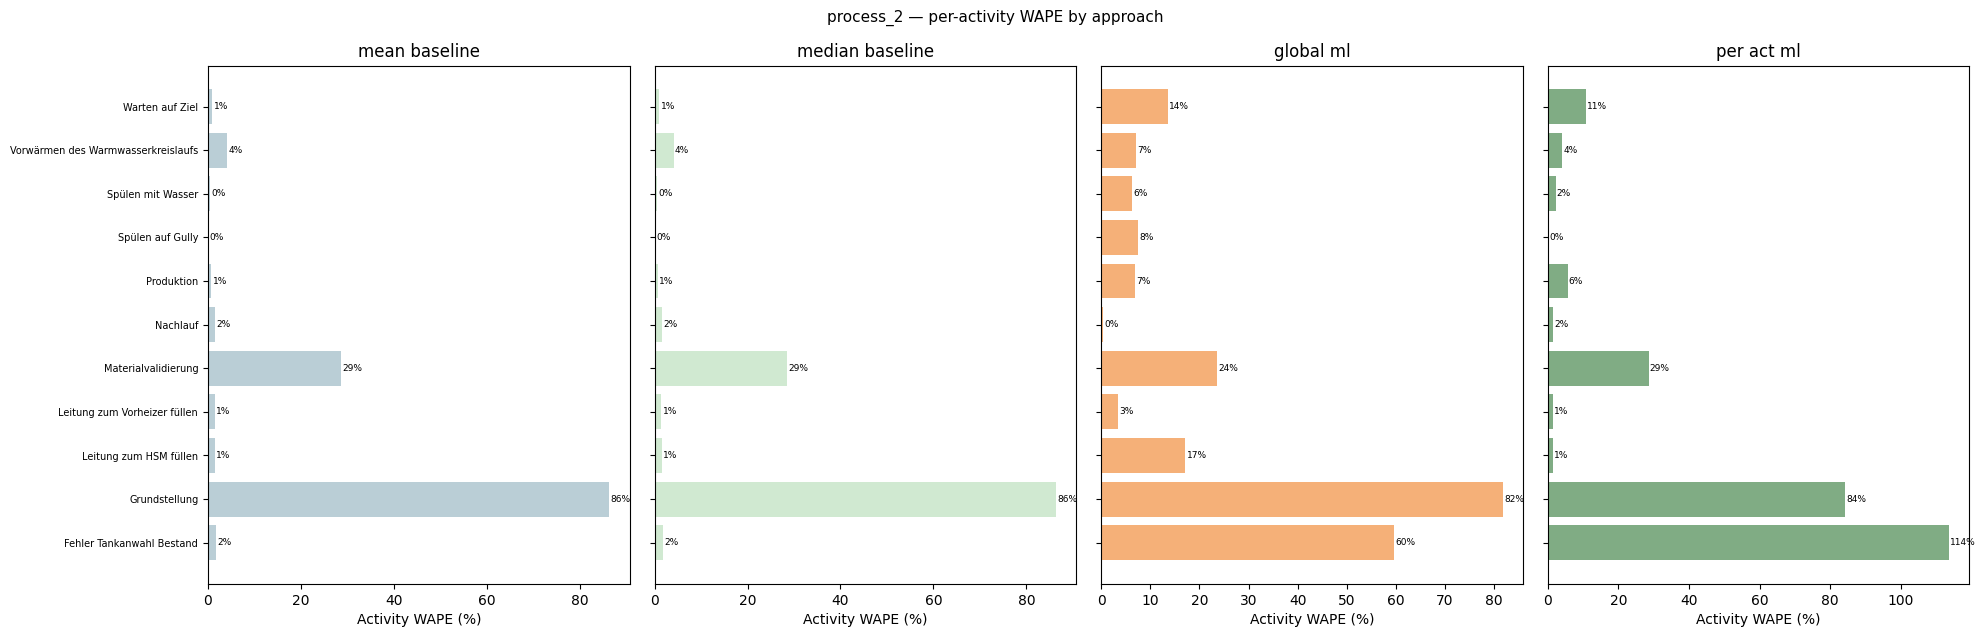

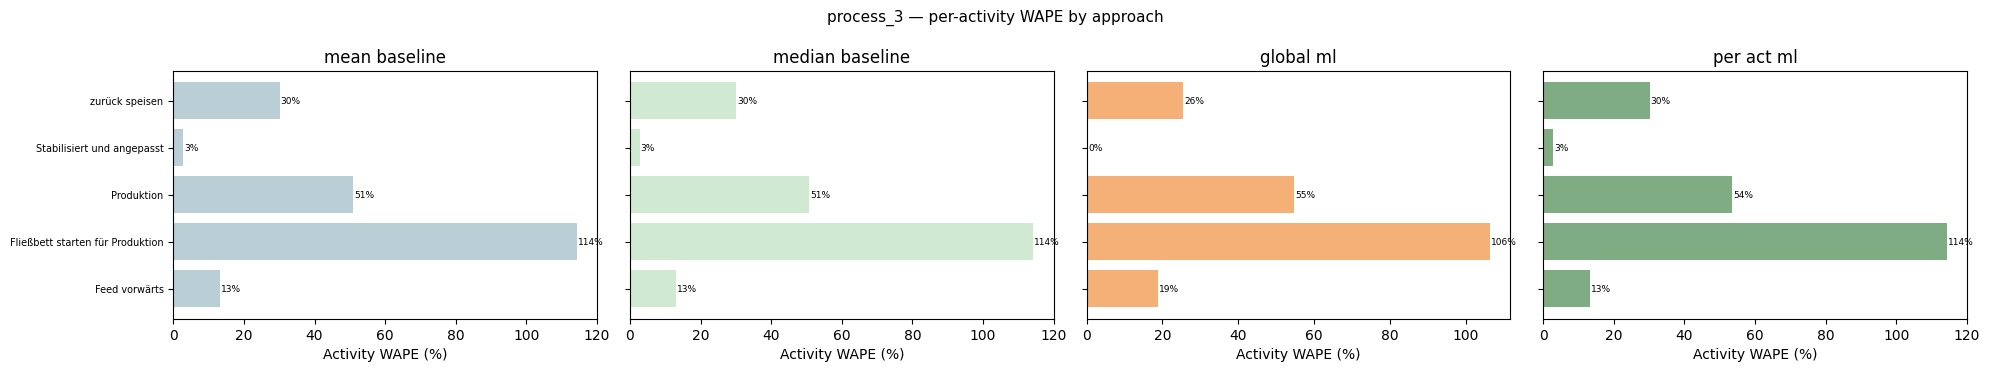

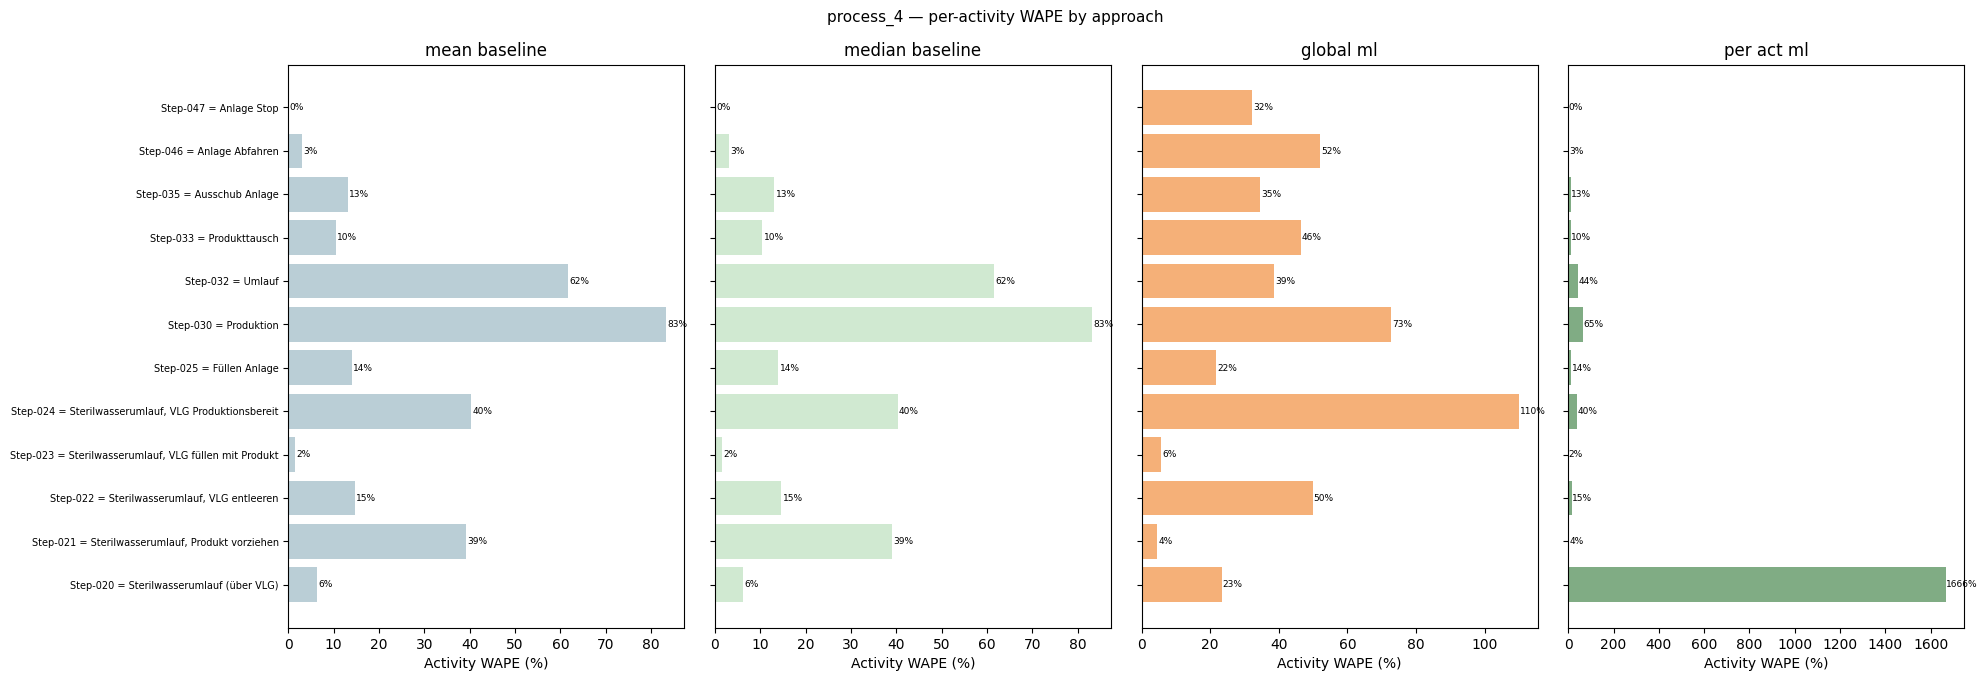

In [8]:
colors = {'mean_baseline':'#aec6cf','median_baseline':'#c8e6c9','global_ml':'#f4a261','per_act_ml':'#6a9e6f'}

for proc in PROCESSES:
    te  = datasets[proc]['test']
    activities = sorted(te['activity'].unique())
    fig, axes = plt.subplots(1, len(APPROACHES),
                             figsize=(5*len(APPROACHES), max(3, 0.45*len(activities)+1.5)),
                             sharey=True)
    for ax, appr in zip(axes, APPROACHES):
        d   = detail[(proc, appr)]
        mu  = d['real_mu'].reindex(activities).fillna(0)
        err = d['abs_err'].reindex(activities).fillna(0)
        pct = (err / mu.replace(0, np.nan)) * 100
        ax.barh(activities, pct, color=colors[appr], alpha=0.85)
        ax.axvline(0, color='k', lw=0.5)
        ax.set_xlabel('Activity WAPE (%)')
        ax.set_title(appr.replace('_',' '))
        ax.tick_params(axis='y', labelsize=7)
        for j, (v, _) in enumerate(zip(pct, activities)):
            if not np.isnan(v): ax.text(v+0.3, j, f'{v:.0f}%', va='center', fontsize=6.5)
    fig.suptitle(f'{proc} — per-activity WAPE by approach', fontsize=11)
    plt.tight_layout(); plt.show()

## 8  Root-cause analysis

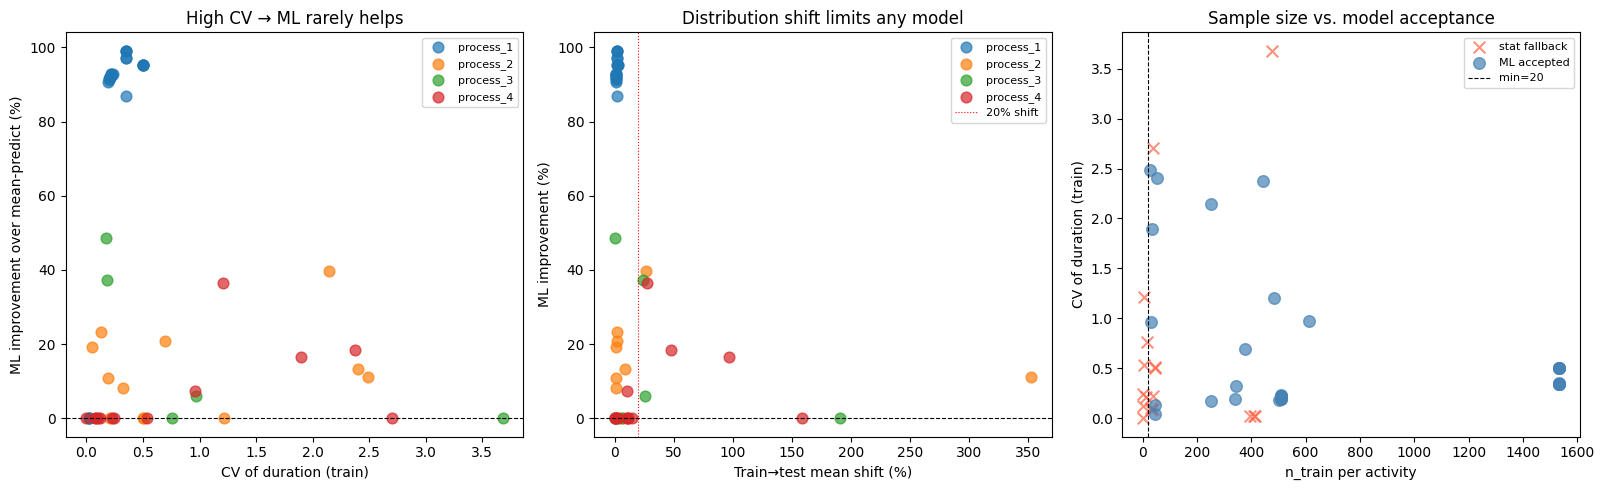

Summary per process:


,n_activities,ml_accepted,mean_CV,mean_shift_pct,mean_ML_improvement_pct
process,,,,,
process_1,22,19,0.27,1.36,81.28
process_2,12,8,0.91,36.96,12.21
process_3,5,3,1.15,49.24,18.38
process_4,13,4,0.81,32.66,6.04


In [9]:
rca_rows = []
for proc in PROCESSES:
    m  = proc_models[proc]
    tr = datasets[proc]['train']
    te = datasets[proc]['test']
    for act, info in m['act_models'].items():
        tr_a = tr[tr['activity']==act]['duration']
        te_a = te[te['activity']==act]['duration'] if act in te['activity'].values else pd.Series([], dtype=float)
        mu_tr = tr_a.mean() if len(tr_a)>0 else np.nan
        mu_te = te_a.mean() if len(te_a)>0 else np.nan
        cv_tr  = tr_a.std()/mu_tr if (mu_tr and mu_tr>0 and len(tr_a)>1) else np.nan
        shift  = abs(mu_tr-mu_te)/mu_te if (mu_te and mu_te>0) else np.nan
        rca_rows.append({'process':proc,'activity':act,'n_train':len(tr_a),'cv_train':cv_tr,
                         'mean_shift':shift,'ml_accepted':info['type']=='ml',
                         'cv_score':info.get('cv_score',np.nan),
                         'baseline_score':info.get('baseline_score',np.nan),
                         'improvement':info.get('improvement',0.0)})
rca_df = pd.DataFrame(rca_rows)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
for proc, grp in rca_df.groupby('process'):
    ax.scatter(grp['cv_train'], grp['improvement']*100, label=proc, alpha=0.7, s=60)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('CV of duration (train)'); ax.set_ylabel('ML improvement over mean-predict (%)')
ax.set_title('High CV → ML rarely helps'); ax.legend(fontsize=8)

ax = axes[1]
for proc, grp in rca_df.groupby('process'):
    ax.scatter(grp['mean_shift']*100, grp['improvement']*100, label=proc, alpha=0.7, s=60)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.axvline(20, color='r', lw=0.8, ls=':', label='20% shift')
ax.set_xlabel('Train→test mean shift (%)'); ax.set_ylabel('ML improvement (%)')
ax.set_title('Distribution shift limits any model'); ax.legend(fontsize=8)

ax = axes[2]
acc = rca_df[rca_df['ml_accepted']]; rej = rca_df[~rca_df['ml_accepted']]
ax.scatter(rej['n_train'], rej['cv_train'], marker='x', color='tomato', alpha=0.7, s=70, label='stat fallback')
ax.scatter(acc['n_train'], acc['cv_train'], marker='o', color='steelblue', alpha=0.7, s=70, label='ML accepted')
ax.axvline(MIN_SAMPLES, color='k', ls='--', lw=0.8, label=f'min={MIN_SAMPLES}')
ax.set_xlabel('n_train per activity'); ax.set_ylabel('CV of duration (train)')
ax.set_title('Sample size vs. model acceptance'); ax.legend(fontsize=8)

plt.tight_layout(); plt.show()

print('Summary per process:')
display(rca_df.groupby('process').agg(
    n_activities=('activity','count'), ml_accepted=('ml_accepted','sum'),
    mean_CV=('cv_train','mean'),
    mean_shift_pct=('mean_shift', lambda x: (x*100).mean()),
    mean_ML_improvement_pct=('improvement', lambda x: (x*100).mean()),
).round(2))

### 8b  Feature correlation with log-duration

If |r| < 0.1 for all features → ML can never beat the mean-predict baseline.

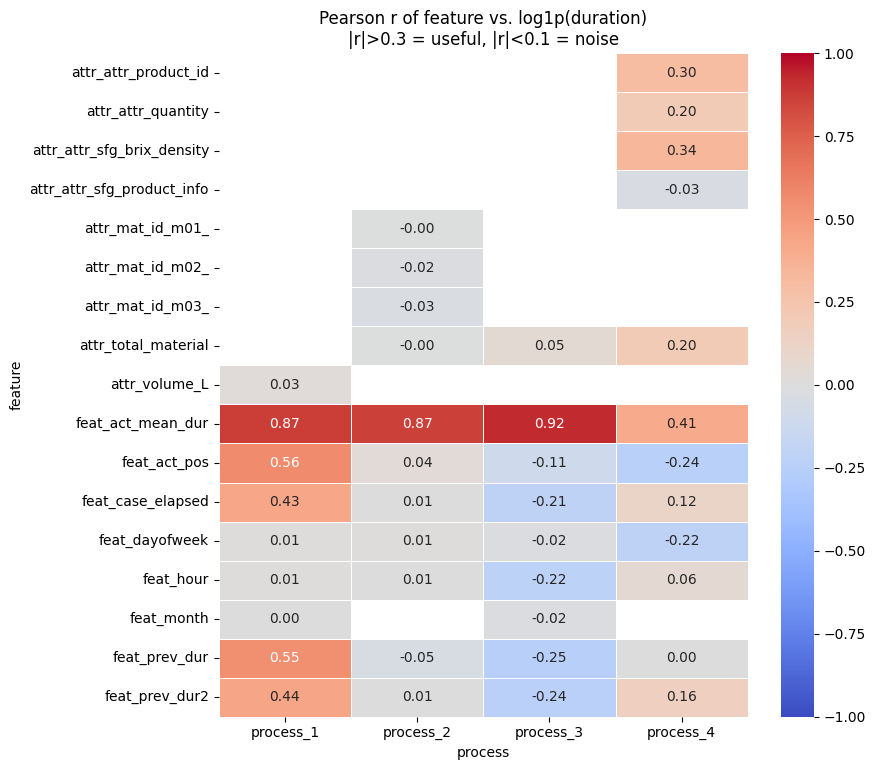

Top 5 features per process (by |r|):
  process_1:
    feat_act_mean_dur                    r=+0.872
    feat_act_pos                         r=+0.563
    feat_prev_dur                        r=+0.552
    feat_prev_dur2                       r=+0.438
    feat_case_elapsed                    r=+0.430
  process_2:
    feat_act_mean_dur                    r=+0.867
    feat_prev_dur                        r=-0.046
    feat_act_pos                         r=+0.036
    attr_mat_id_m03_                     r=-0.029
    attr_mat_id_m02_                     r=-0.016
  process_3:
    feat_act_mean_dur                    r=+0.922
    feat_prev_dur                        r=-0.251
    feat_prev_dur2                       r=-0.241
    feat_hour                            r=-0.220
    feat_case_elapsed                    r=-0.215
  process_4:
    feat_act_mean_dur                    r=+0.410
    attr_attr_sfg_brix_density           r=+0.342
    attr_attr_product_id                 r=+0.301
    feat_ac

In [10]:
corr_rows = []
for proc in PROCESSES:
    tr = datasets[proc]['train']
    m  = proc_models[proc]
    tr_f, feat_cols = prepare_features(tr, m['act_means'], m['global_mean'])
    y_log = np.log1p(tr_f['duration'].values)
    for fc in feat_cols:
        x = pd.to_numeric(tr_f[fc], errors='coerce').fillna(0).values
        try: r, p = pearsonr(x, y_log)
        except: r, p = np.nan, np.nan
        corr_rows.append({'process':proc,'feature':fc,'pearson_r':r,'p_value':p})

corr_df = pd.DataFrame(corr_rows)
corr_pivot = corr_df.pivot(index='feature', columns='process', values='pearson_r').round(3)

fig, ax = plt.subplots(figsize=(9, max(4, 0.4*len(corr_pivot)+1)))
sns.heatmap(corr_pivot, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1,
            linewidths=0.4, ax=ax)
ax.set_title('Pearson r of feature vs. log1p(duration)\n|r|>0.3 = useful, |r|<0.1 = noise')
plt.tight_layout(); plt.show()

print('Top 5 features per process (by |r|):')
for proc in PROCESSES:
    sub = corr_df[corr_df['process']==proc].copy()
    sub['abs_r'] = sub['pearson_r'].abs()
    print(f'  {proc}:')
    for _, row in sub.nlargest(5,'abs_r').iterrows():
        print(f'    {row["feature"]:35s}  r={row["pearson_r"]:+.3f}')

### 8c  Why is median sometimes better than mean?

Right-skewed distributions (high positive skewness) make the mean sensitive to outliers.  
The median is the WAPE-optimal constant predictor for skewed data.

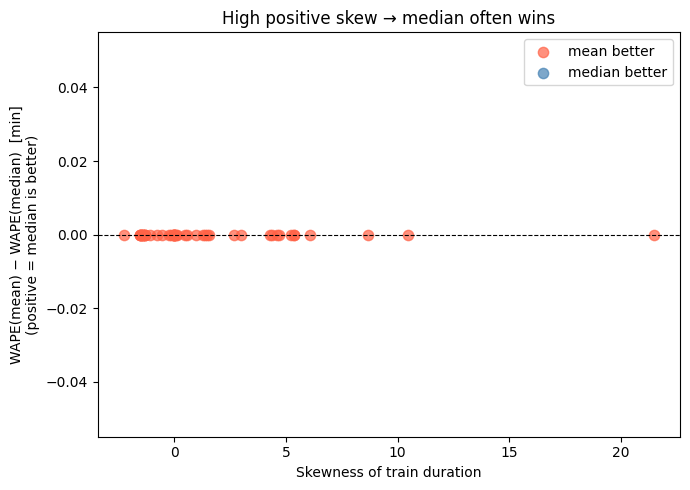

Activities where median outperforms mean:


,process,activity,skewness,wape_mean,wape_median


In [11]:
skew_rows = []
for proc, ds in datasets.items():
    tr = ds['train']
    for act, grp in tr.groupby('activity'):
        d  = grp['duration'].dropna()
        sk = float(d.skew()) if len(d)>2 else np.nan
        mw = detail[(proc,'mean_baseline')]['abs_err'].get(act, np.nan)
        dw = detail[(proc,'median_baseline')]['abs_err'].get(act, np.nan)
        skew_rows.append({'process':proc,'activity':act,'skewness':sk,
                          'wape_mean':mw,'wape_median':dw,
                          'median_better': (dw < mw) if not (pd.isna(dw) or pd.isna(mw)) else np.nan})
skew_df = pd.DataFrame(skew_rows)

fig, ax = plt.subplots(figsize=(7, 5))
better = skew_df[skew_df['median_better']==True]
worse  = skew_df[skew_df['median_better']==False]
ax.scatter(worse['skewness'],  worse['wape_mean']  - worse['wape_median'],  color='tomato',    alpha=0.7, s=55, label='mean better')
ax.scatter(better['skewness'], better['wape_mean'] - better['wape_median'], color='steelblue', alpha=0.7, s=55, label='median better')
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set_xlabel('Skewness of train duration')
ax.set_ylabel('WAPE(mean) − WAPE(median)  [min]\n(positive = median is better)')
ax.set_title('High positive skew → median often wins')
ax.legend(); plt.tight_layout(); plt.show()

print('Activities where median outperforms mean:')
display(skew_df[skew_df['median_better']==True]
        .sort_values('skewness', ascending=False)
        [['process','activity','skewness','wape_mean','wape_median']].round(2).reset_index(drop=True))

## 9  Per-activity model report

In [12]:
report_rows = []
for proc in PROCESSES:
    m  = proc_models[proc]
    tr = datasets[proc]['train']
    for act, info in sorted(m['act_models'].items()):
        tr_a = tr[tr['activity']==act]['duration']
        cv_tr = tr_a.std()/tr_a.mean() if tr_a.mean()>0 else np.nan
        report_rows.append({'process':proc,'activity':act,'n_train':info['n'],
                            'cv_train':round(cv_tr,3),'ml_accepted':info['type']=='ml',
                            'model':info.get('model_name','—'),
                            'cv_MAE(log1p)':round(info.get('cv_score',np.nan),4),
                            'baseline_MAE': round(info.get('baseline_score',np.nan),4),
                            'improvement_%':round(info.get('improvement',0)*100,1)})
report_df = pd.DataFrame(report_rows)
display(report_df.style
    .applymap(lambda v: 'background-color:#d4edda' if v is True else ('background-color:#f8d7da' if v is False else ''), subset=['ml_accepted'])
    .set_caption('Green=ML accepted | Red=statistical fallback'))

,process,activity,n_train,cv_train,ml_accepted,model,cv_MAE(log1p),baseline_MAE,improvement_%
0,process_1,autoclaving_1_cool,511,0.205000,True,huber,0.015100,0.189500,92.100000
1,process_1,autoclaving_1_heat,511,0.196000,True,rf,0.015600,0.174700,91.100000
2,process_1,autoclaving_1_hold,511,0.223000,True,huber,0.014800,0.201300,92.600000
3,process_1,autoclaving_1_prepare,409,0.020000,False,statistical,0.010700,0.011000,0.000000
4,process_1,autoclaving_2_cool,511,0.203000,True,huber,0.015600,0.186800,91.600000
5,process_1,autoclaving_2_heat,511,0.194000,True,huber,0.016100,0.172600,90.700000
6,process_1,autoclaving_2_hold,511,0.220000,True,huber,0.013900,0.198300,93.000000
7,process_1,autoclaving_2_prepare,412,0.020000,False,statistical,0.010900,0.010900,0.000000
8,process_1,autoclaving_3_cool,511,0.217000,True,huber,0.014800,0.207800,92.900000
9,process_1,autoclaving_3_heat,511,0.208000,True,rf,0.015600,0.192000,91.900000


## 10  Residual analysis (per-act ML on test)

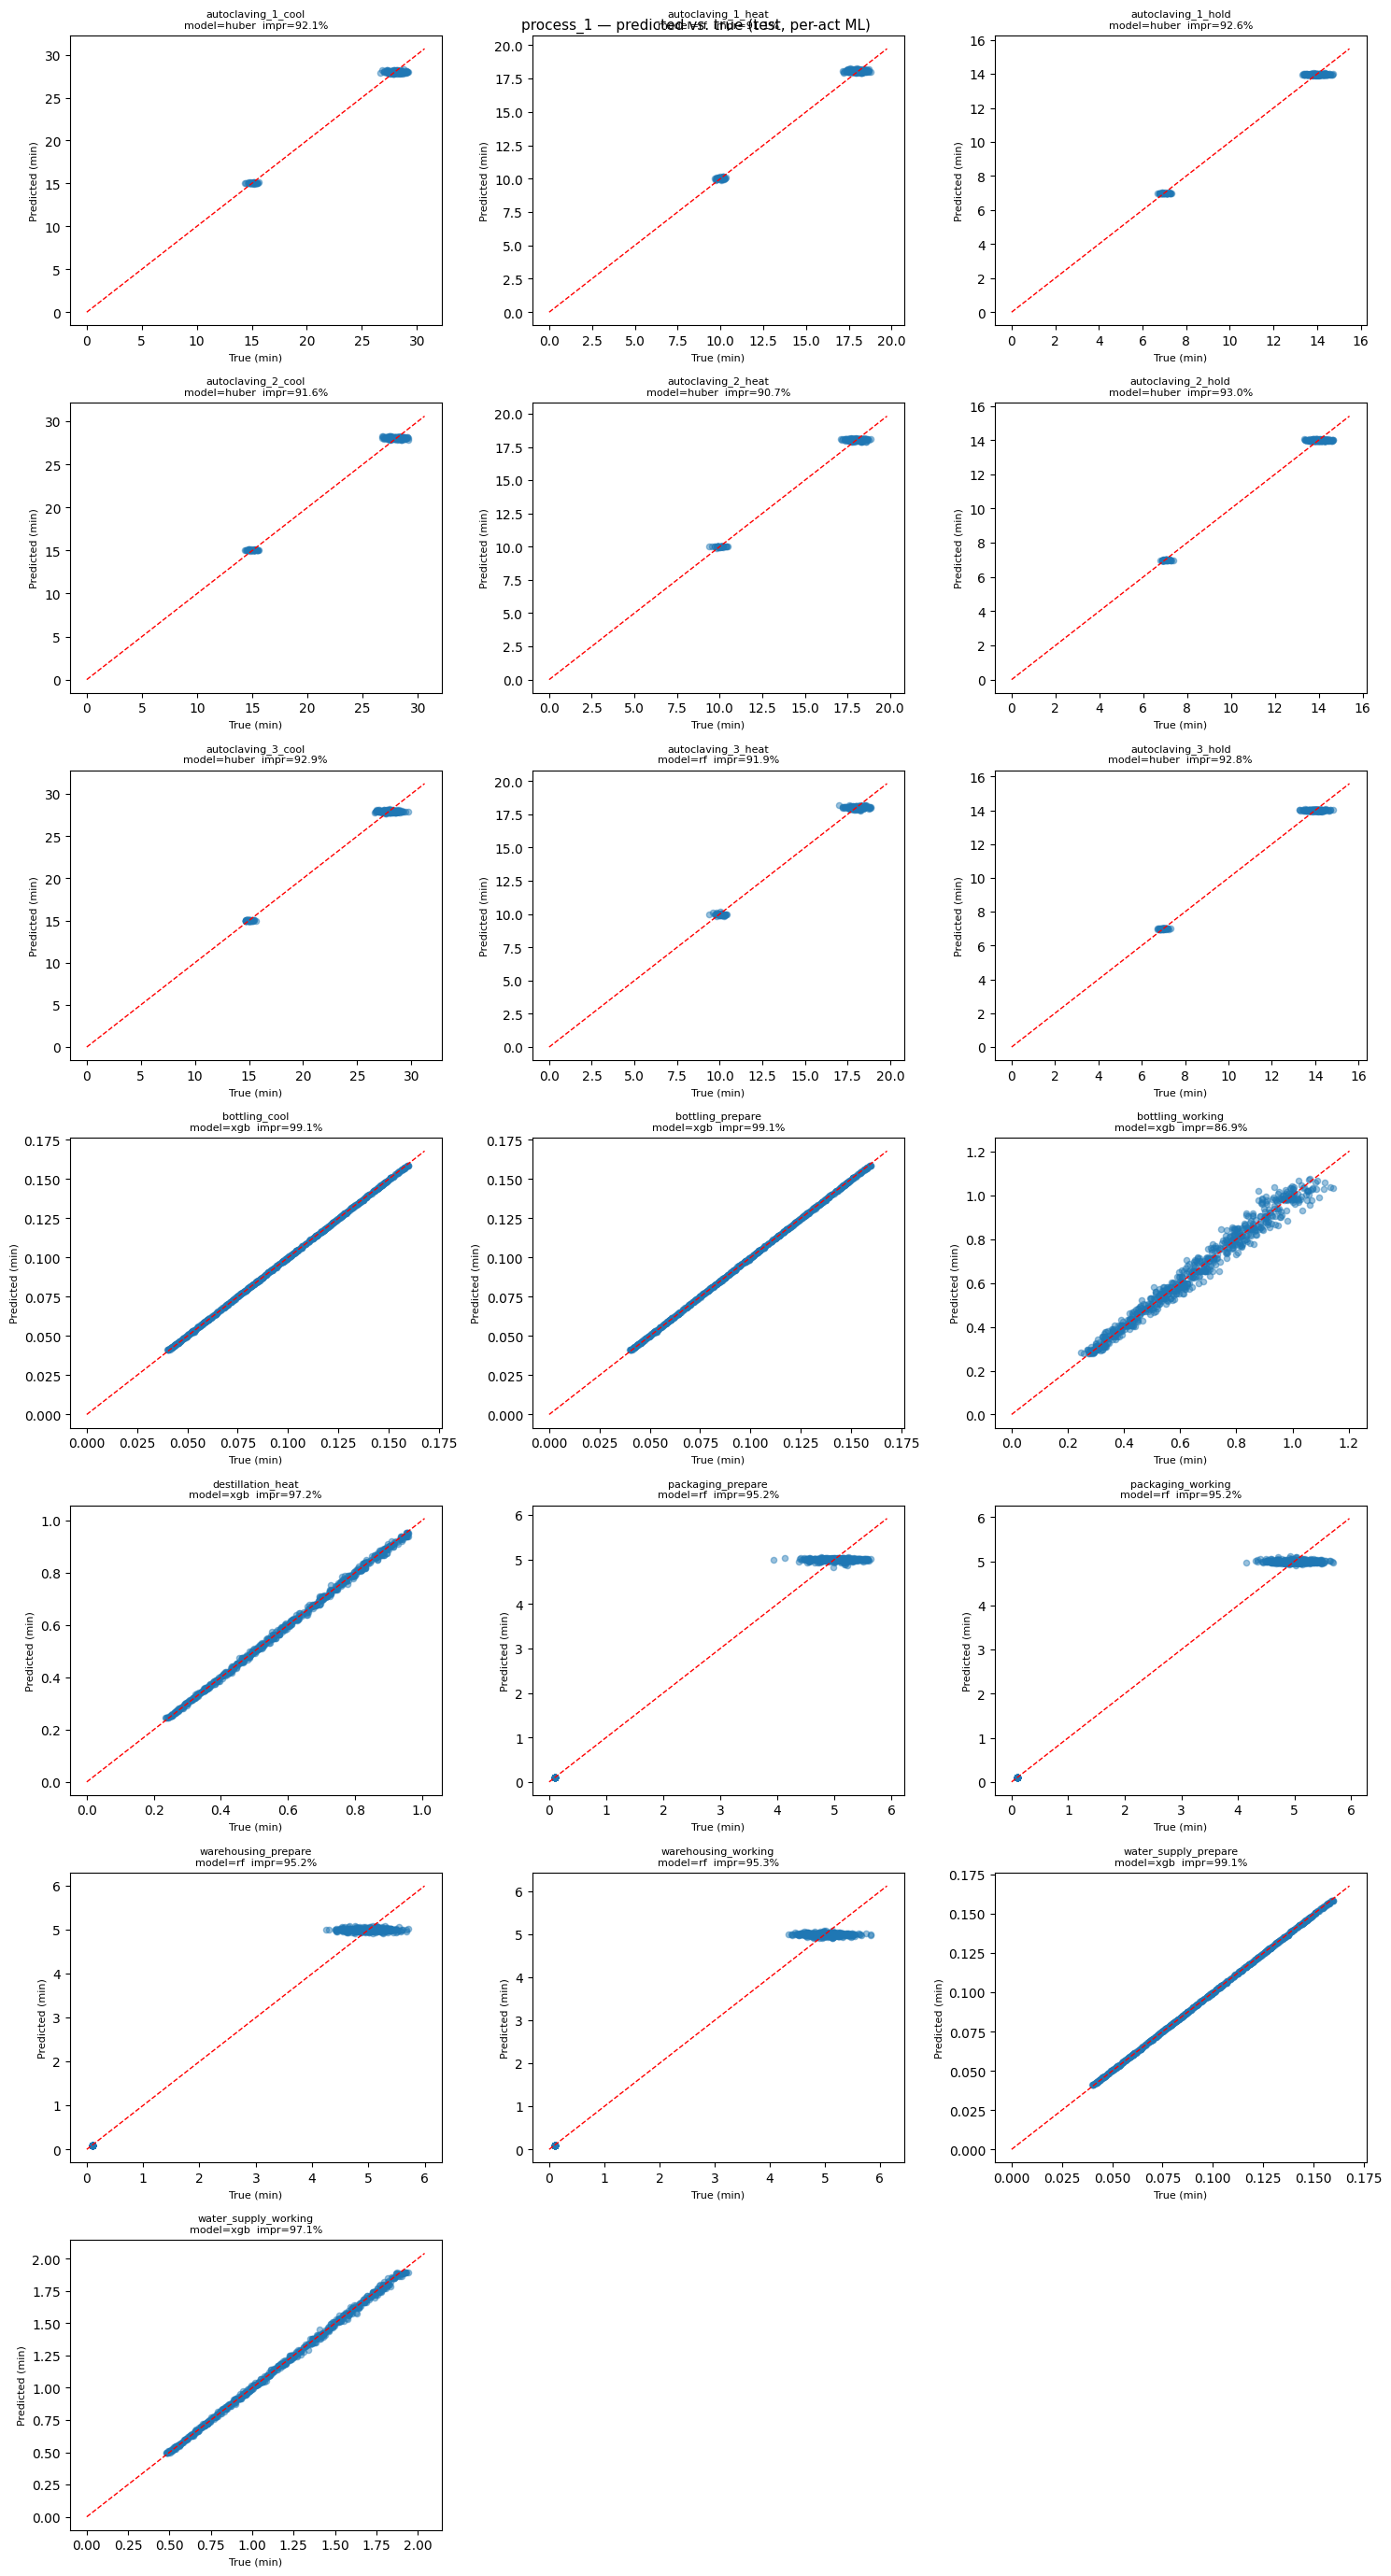

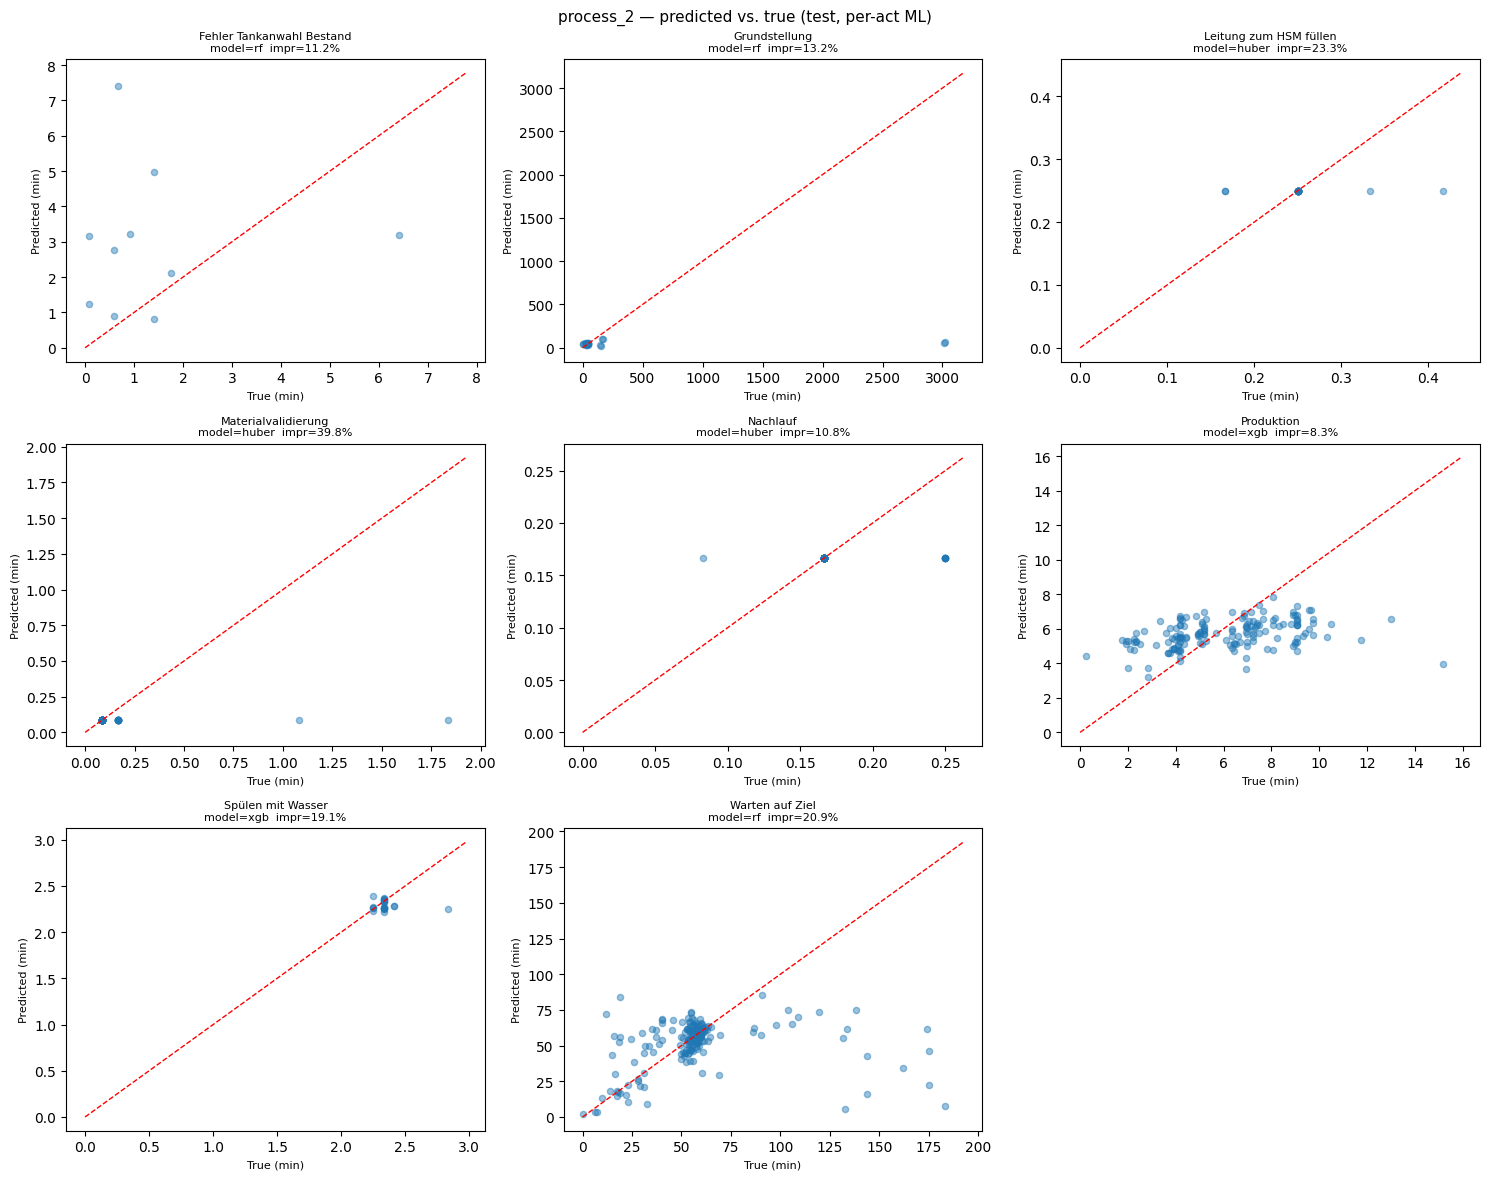

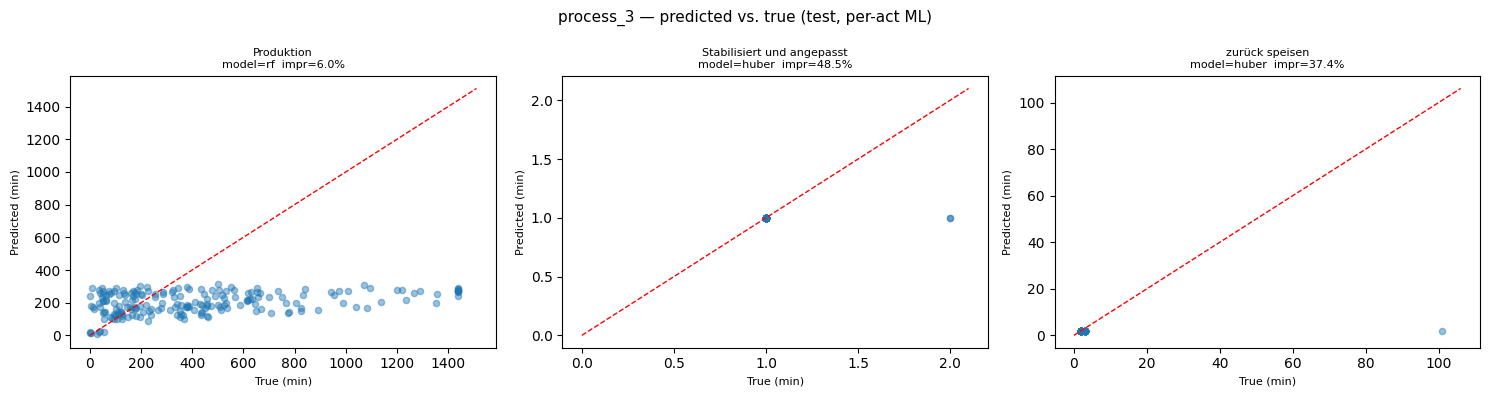

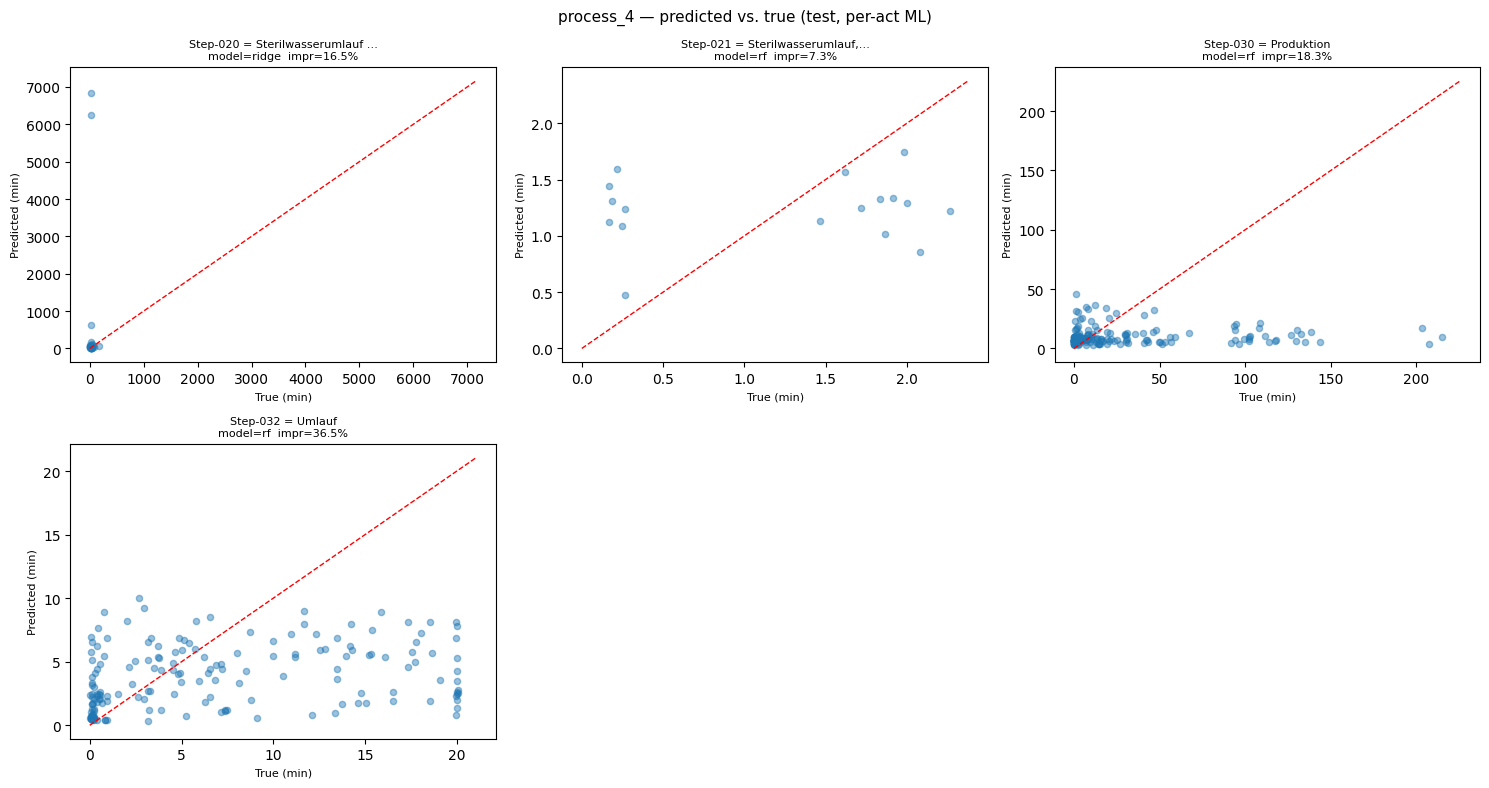

In [13]:
for proc in PROCESSES:
    m  = proc_models[proc]
    tr = datasets[proc]['train']
    te = datasets[proc]['test']
    te_f, feat_cols = prepare_features(te, m['act_means'], m['global_mean'])
    ml_acts = [a for a, info in m['act_models'].items() if info['type']=='ml']
    if not ml_acts:
        print(f'{proc}: no ML models accepted.'); continue
    n_cols = min(3, len(ml_acts))
    n_rows = int(np.ceil(len(ml_acts)/n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
    axes = np.array(axes).flatten()
    for i, act in enumerate(ml_acts):
        info = m['act_models'][act]
        sub  = te_f[te_f['activity']==act]
        if sub.empty: axes[i].set_visible(False); continue
        X    = make_X(sub, feat_cols)
        pred = np.expm1(info['model'].predict(info['scaler'].transform(X)))
        true = sub['duration'].values
        ax   = axes[i]
        mx   = max(true.max(), pred.max())*1.05
        ax.scatter(true, pred, alpha=0.45, s=20)
        ax.plot([0,mx],[0,mx],'r--',lw=1)
        ax.set_xlabel('True (min)',fontsize=8); ax.set_ylabel('Predicted (min)',fontsize=8)
        short = act[:30]+('…' if len(act)>30 else '')
        ax.set_title(f"{short}\nmodel={info['model_name']}  impr={info['improvement']*100:.1f}%",fontsize=8)
    for j in range(i+1, len(axes)): axes[j].set_visible(False)
    fig.suptitle(f'{proc} — predicted vs. true (test, per-act ML)',fontsize=11)
    plt.tight_layout(); plt.show()

## 11  Diagnosis & recommendations

In [14]:
print('='*70)
for proc in PROCESSES:
    m = proc_models[proc]
    get_w = lambda appr: next(r['WAPE_%'] for r in wape_rows if r['process']==proc and r['approach']==appr)
    w_mean, w_med, w_gml, w_pa = [get_w(a) for a in APPROACHES]
    n_ml   = sum(1 for v in m['act_models'].values() if v['type']=='ml')
    n_tot  = len(m['act_models'])
    prc    = rca_df[rca_df['process']==proc]
    mean_cv    = float(prc['cv_train'].mean())
    mean_shift = float(prc['mean_shift'].mean()*100)

    print(f'\n── {proc} ──')
    print(f'  WAPE: mean={w_mean:.1f}%  median={w_med:.1f}%  global_ml={w_gml:.1f}%  per_act_ml={w_pa:.1f}%')
    print(f'  ML accepted: {n_ml}/{n_tot}  |  mean CV={mean_cv:.2f}  |  mean shift={mean_shift:.1f}%')
    causes = []
    if mean_shift > 25:
        causes.append(f'DISTRIBUTION SHIFT ({mean_shift:.0f}%): train/test means differ.\n'
                      '   → Use rolling or online-updated models; or check data generation stability.')
    if mean_cv > 0.5:
        causes.append(f'HIGH NATURAL VARIANCE (CV={mean_cv:.2f}): duration is inherently noisy.\n'
                      '   → Point-prediction WAPE will always be high; consider sampling from fitted distribution.')
    if n_ml < n_tot//2:
        causes.append(f'FEW ML WINS ({n_ml}/{n_tot}): existing features not informative enough.\n'
                      '   → See cell 8b for correlations; add batch-size, operator, shift, material-type features.')
    if w_med < w_mean:
        causes.append(f'MEDIAN BEATS MEAN ({w_med:.1f}% vs {w_mean:.1f}%): right-skewed duration dist.\n'
                      '   → Switch statistical baseline from mean to median in activity_config.')
    if not causes:
        causes.append('No severe issues detected — WAPE reflects the task difficulty.')
    for c in causes:
        print('  ⚠ ' + c.replace('\n','\n    '))
print('\n'+'='*70)


── process_1 ──
  WAPE: mean=9.5%  median=9.5%  global_ml=2.7%  per_act_ml=0.2%
  ML accepted: 19/22  |  mean CV=0.27  |  mean shift=1.4%
  ⚠ No severe issues detected — WAPE reflects the task difficulty.

── process_2 ──
  WAPE: mean=70.4%  median=70.4%  global_ml=68.9%  per_act_ml=70.6%
  ML accepted: 8/12  |  mean CV=0.91  |  mean shift=37.0%
  ⚠ DISTRIBUTION SHIFT (37%): train/test means differ.
       → Use rolling or online-updated models; or check data generation stability.
  ⚠ HIGH NATURAL VARIANCE (CV=0.91): duration is inherently noisy.
       → Point-prediction WAPE will always be high; consider sampling from fitted distribution.

── process_3 ──
  WAPE: mean=50.6%  median=50.6%  global_ml=54.4%  per_act_ml=53.2%
  ML accepted: 3/5  |  mean CV=1.15  |  mean shift=49.2%
  ⚠ DISTRIBUTION SHIFT (49%): train/test means differ.
       → Use rolling or online-updated models; or check data generation stability.
  ⚠ HIGH NATURAL VARIANCE (CV=1.15): duration is inherently noisy.
   